In [1]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

## Conditional optimization: Relaxed bounds and local perturbation restart

The purpose of this conditional optimization is to check the stability of the parameters found by the main optimization protocol. To test the stability:

1) Load the parameters from the main optimization protocol.
2) Apply a local perturbation to the loaded parameters by adding uniform noise.
3) Renormalize the perturbed parameters into an expanded boundary range.
4) Load the perturbed renormalized parameters into a new instance of the model with relaxed parameter bounds.
5) Reoptimize.
6) Check if the loss and parameter distributions have diverged from the those of the main optimization protocol.

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

relaxed_param_bounds = {
    "fts": [-1000.0, 1000.0],
    "t": [-1000.0, 1000.0],
    "ampc": [0.01, 10.0],
    'ampm': [-100.0, 100.0],
    "ampg": [0.01, 100.0],
    "ampw": [0.01, 10.0],
    "d": [0, 1000.0],
    "inh_d": [0, 1000.0],
    "inh_w": [-100.0, 100.0],
}

In [6]:
sgcc = SGCCircuit(param_bounds)

In [7]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_3_11_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [8]:
sgcc.load_saved_parameters(
        {x[0]:x[1] + tf.random.uniform(x[1].shape, -1, 1) 
        for x in optimized_model['final_epoch_params'].items()}
    
    )

In [9]:
def renorm(sgcc, newbounds):

    dlgn_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[:-2]
    dlgn_lower = tf.reshape(dlgn_bounds[:,0], [1,1,1,-1,1,1])
    dlgn_upper = tf.reshape(dlgn_bounds[:,1], [1,1,1,-1,1,1])

    v1_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[-2:]
    v1_lower = tf.reshape(v1_bounds[:,0], [1,1,1,-1,1,1])
    v1_upper = tf.reshape(v1_bounds[:,1], [1,1,1,-1,1,1])

    params = {
        'dLGN_params': sgcc.inverse_dlgn_property(
            sgcc.variable_transformer(sgcc.params['dLGN_params'], dlgn_lower, dlgn_upper, 'normalize')
        ),
        'V1_params': sgcc.variable_transformer(sgcc.params['V1_params'], v1_lower, v1_upper, 'normalize')
    }

    return params

In [10]:
renormed_params = renorm(sgcc, relaxed_param_bounds)

In [11]:
model = SGCCircuit(relaxed_param_bounds)

In [12]:
model.load_saved_parameters(renormed_params)

In [13]:
# initialize the optimizer
optimizer = Optimize(model, epochs=2000, loss_threshold=0)

# fit the model
loss_decay = optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002C2BB4CE0A0>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.18510669469833374
med_loss = 0.9201996326446533
max_loss = 4.462993621826172

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.07922607660293579
med_loss = 0.11780419945716858
max_loss = 0.26947981119155884

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.07624608278274536
med_loss = 0.09816688299179077
max_loss = 0.24785830080509186

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.07442886382341385
med_loss = 0.08883191645145416
max_loss = 0.2440948188304901

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.07285488396883011
med_loss = 0.08355845510959625
max_loss = 0.24236857891082764

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.07090619206428528
med_loss = 0.0805901437997818
max_loss = 0.24124641716480255

Training step = 600, N_exploration_samp

In [14]:
optimizer.save_state('conditional_optimization_relaxedbounds_plus_perturbation')

In [15]:
loss_decay = loss_decay.numpy()
param_history = optimizer.outputs['param_history']

In [16]:
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 439, loss = 0.06585693359375


In [17]:
def minmax_norm(array, lower, upper):
    if (array.max() - array.min()) != 0:
        norm = (array - array.min()) / (array.max() - array.min())
        return lower + (norm * (upper-lower))
    else:
        return array

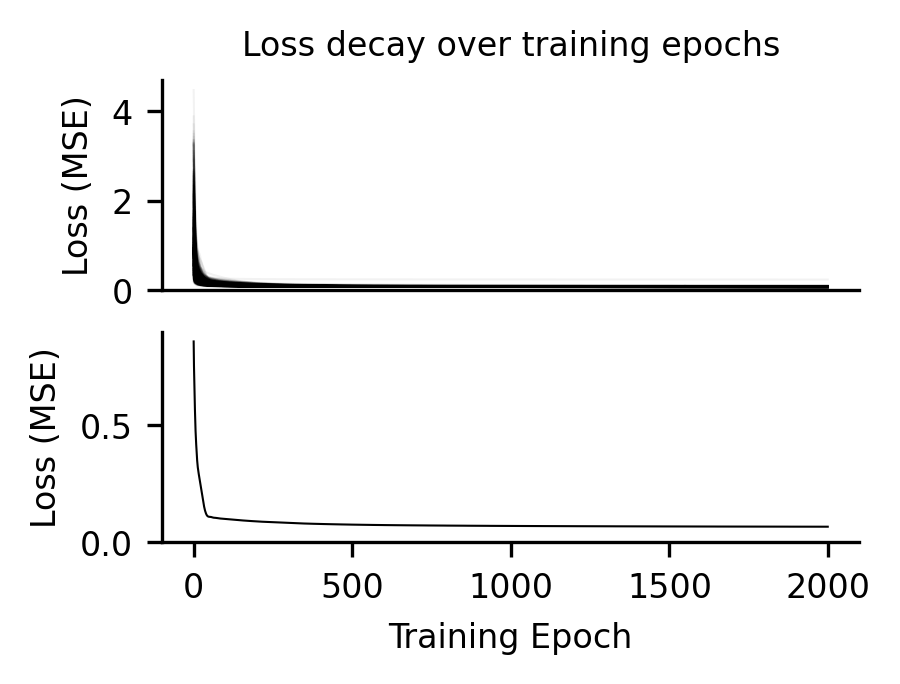

In [18]:
fig, ax = plt.subplots(2, figsize = (3,2))

for i, decay in enumerate(loss_decay.T):
    ax[0].plot(decay, alpha = 0.05, color = 'black', linewidth = linewidth)

ax[1].set_xlabel("Training Epoch", fontsize = fontsize)
ax[0].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[0].set_ylim(0,)
ax[0].set_xticks([])

ax[1].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[1].plot(loss_decay[:,best], alpha = 1, color = 'black', linewidth = linewidth)
ax[1].set_ylim(0.)
ax[0].set_title("Loss decay over training epochs", fontsize = fontsize)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

figname = '2d_model_loss_decay_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.0, 'Loss distribution on final training epoch')

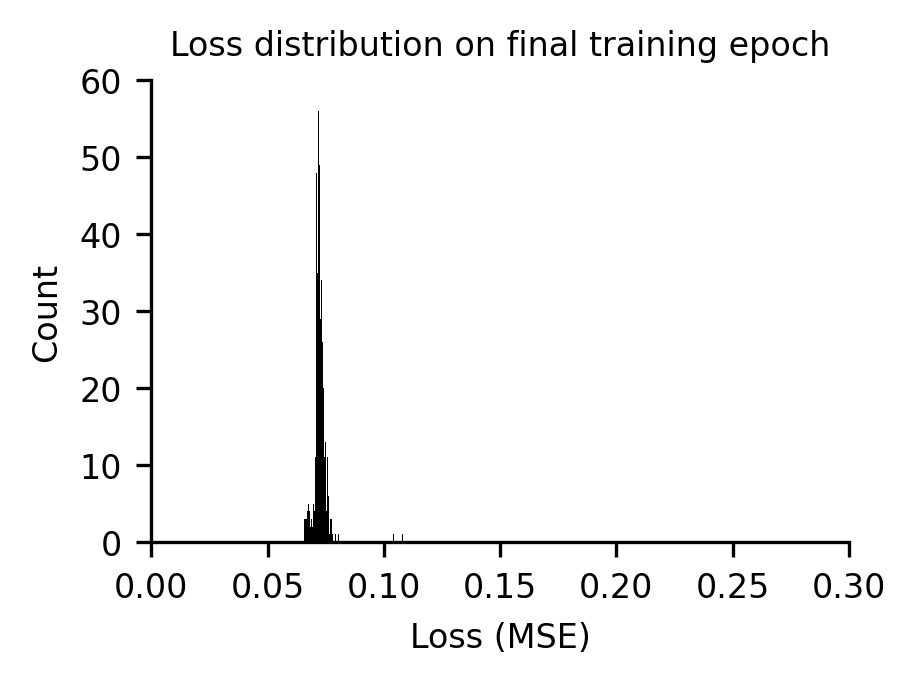

In [19]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(loss_decay[-1], bins = 1000, color = 'black')
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticks(np.arange(0,0.35,0.05))
ax.set_ylim(0,60)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)

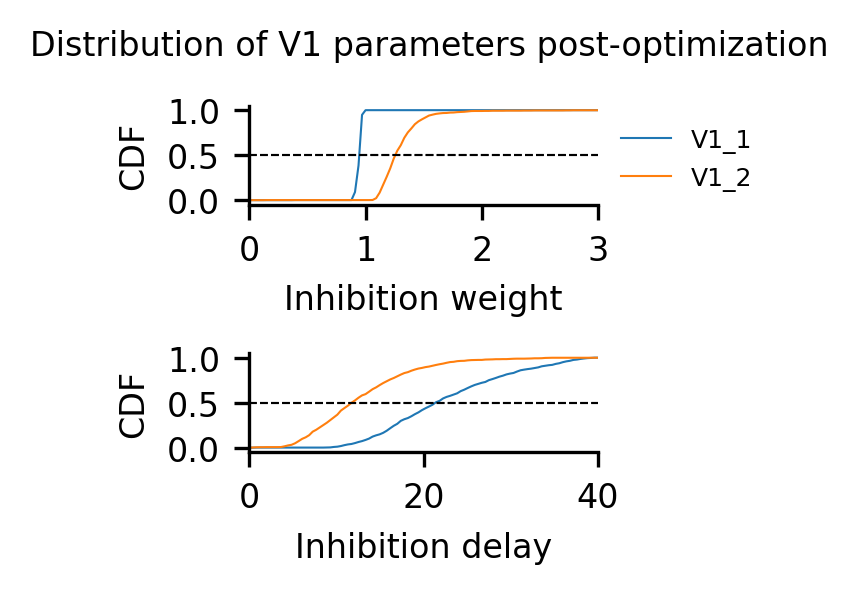

In [20]:
fig, ax = plt.subplots(2,1, figsize = (1.5, 1.5))

for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1],
            100
        )
        data = param_history['V1_params'][:,-1,u,0,i_,0,0]
        kde = ecdf(data).cdf
        y = kde.evaluate(x)

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth)
        ax[i].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
        ax[i].set_xlim(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1]
        )
        ax[i].set_ylabel("CDF", fontsize = fontsize)
        ax[i].set_yticks(np.arange(0, 1.5, 0.5))
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False, bbox_to_anchor = (1,1))
fig.subplots_adjust(hspace=1.5)
plt.suptitle("Distribution of V1 parameters post-optimization", fontsize = fontsize, x = 0.525, y = 1.05)

figname = '2d_model_v1_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

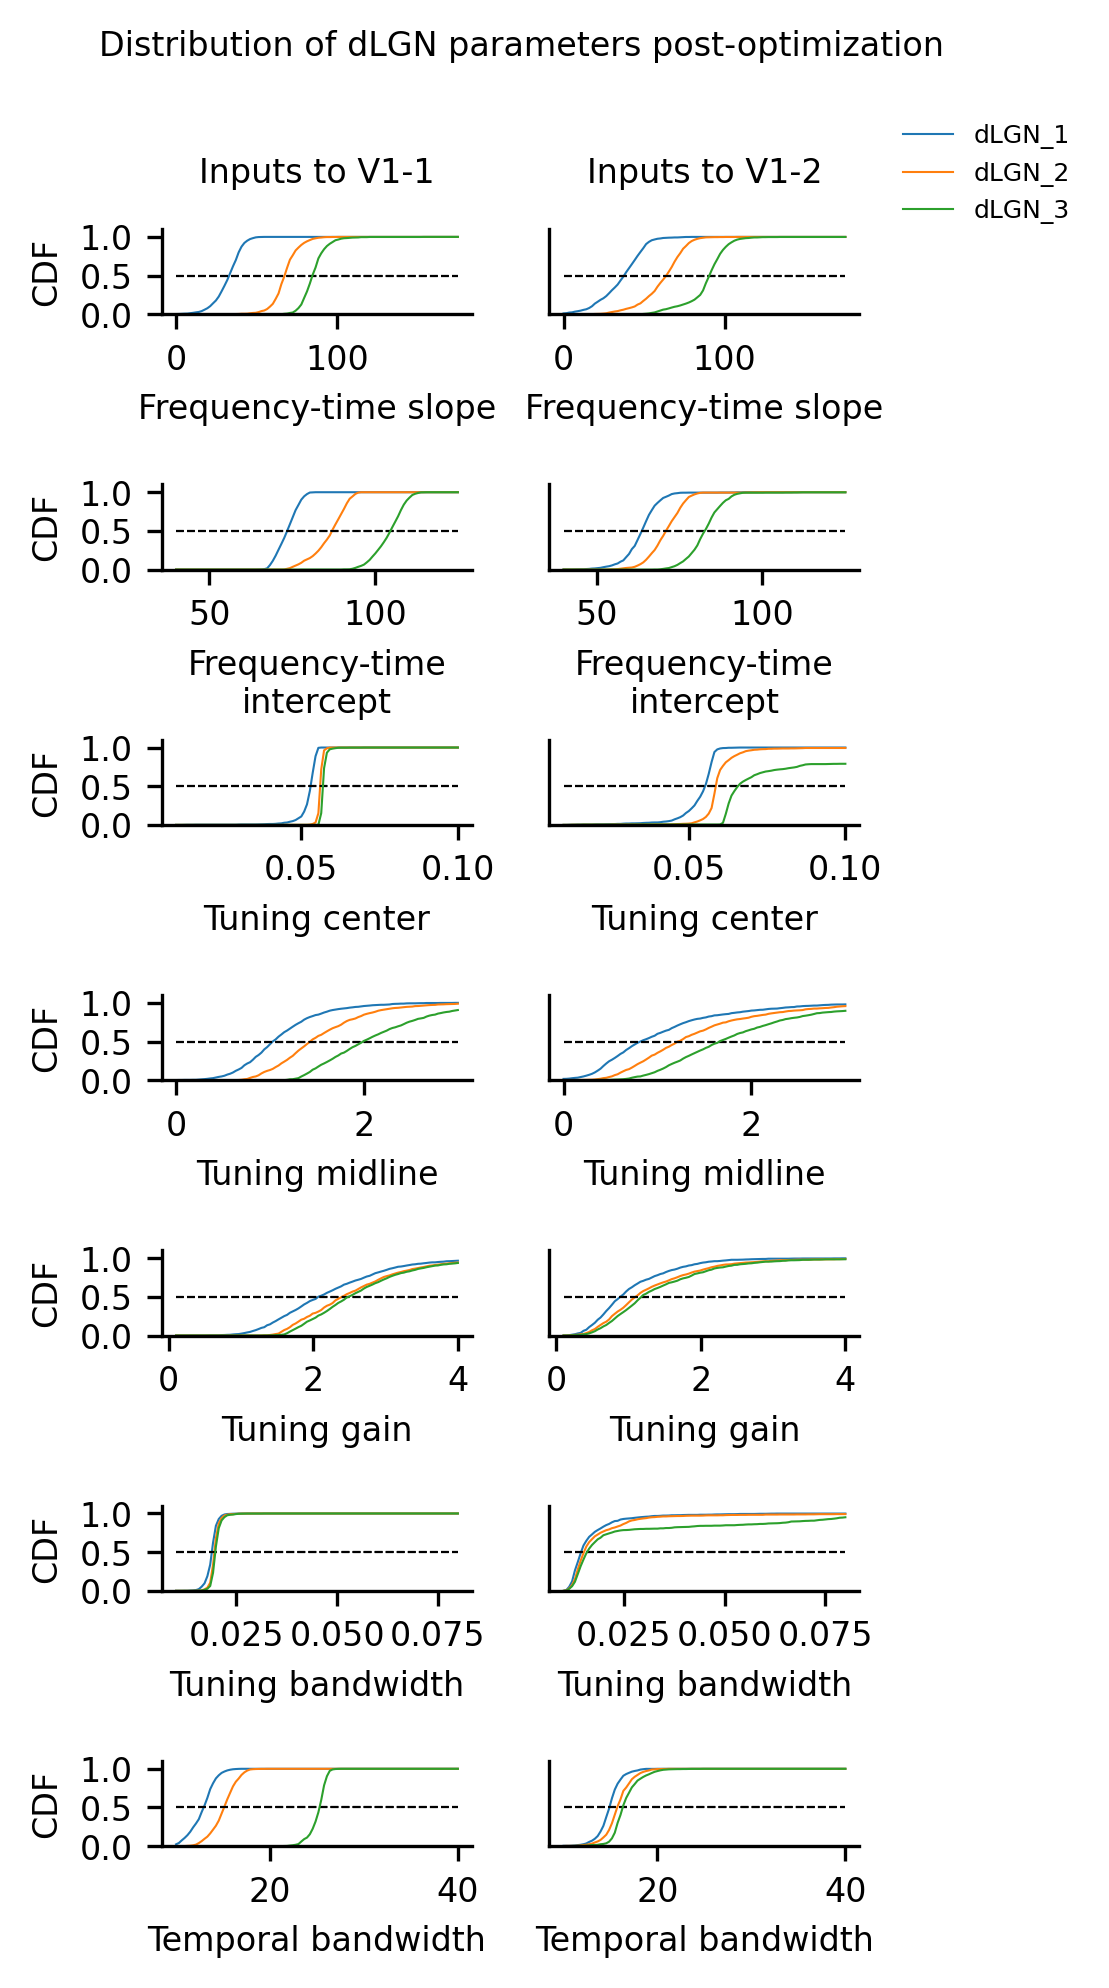

In [21]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.15, 'Convergence of V1 parameter values')

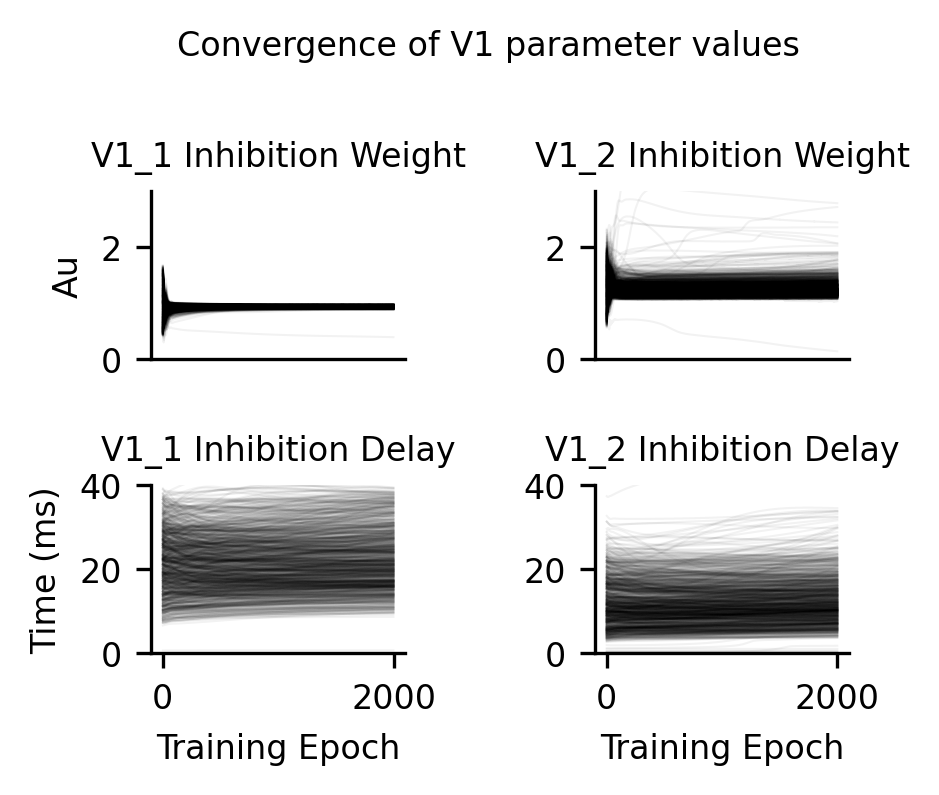

In [22]:
## inhibition weight::inhibition delay

fig, ax = plt.subplots(2,2, figsize = (3,2))

inh_w = 1
v1_n = 0 

for row in range(2):
    for col in range(2):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

ax[0,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# 
v1_n = 1
ax[0,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a0
inh_d = 0
v1_n = 0
ax[1,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a1
v1_n = 1
ax[1,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

ax[0,0].set_ylim(param_bounds['inh_w'][0], param_bounds['inh_w'][1])
ax[0,0].set_title("V1_1 Inhibition Weight", fontsize = fontsize)
ax[0,0].set_xticks([])
ax[0,0].set_ylabel("Au", fontsize = fontsize)

ax[0,1].set_ylim(param_bounds['inh_w'][0], param_bounds['inh_w'][1])
ax[0,1].set_title("V1_2 Inhibition Weight", fontsize = fontsize)
ax[0,1].set_xticks([])

ax[1,0].set_ylim(param_bounds['inh_d'][0], param_bounds['inh_d'][1])
ax[1,0].set_title("V1_1 Inhibition Delay", fontsize = fontsize)
ax[1,0].set_ylabel("Time (ms)", fontsize = fontsize)
ax[1,0].set_xlabel("Training Epoch", fontsize = fontsize)

ax[1,1].set_ylim(param_bounds['inh_d'][0], param_bounds['inh_d'][1])
ax[1,1].set_title("V1_2 Inhibition Delay", fontsize = fontsize)
ax[1,1].set_xlabel("Training Epoch", fontsize = fontsize)
fig.subplots_adjust(wspace=0.75, hspace=0.75)
plt.suptitle("Convergence of V1 parameter values", fontsize = fontsize, y = 1.15)

# figname = '2d_model_v1_param_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

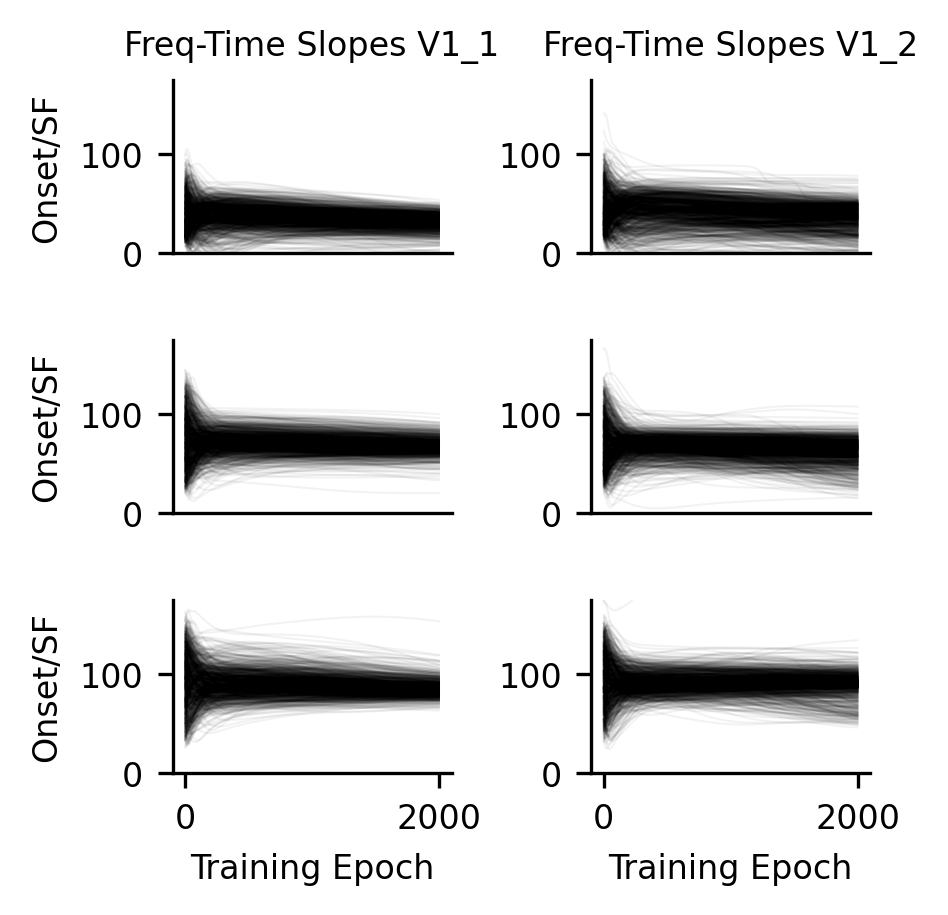

In [23]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 0

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Freq-Time Slopes V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Onset/SF", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['fts'][0], param_bounds['fts'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_fts_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

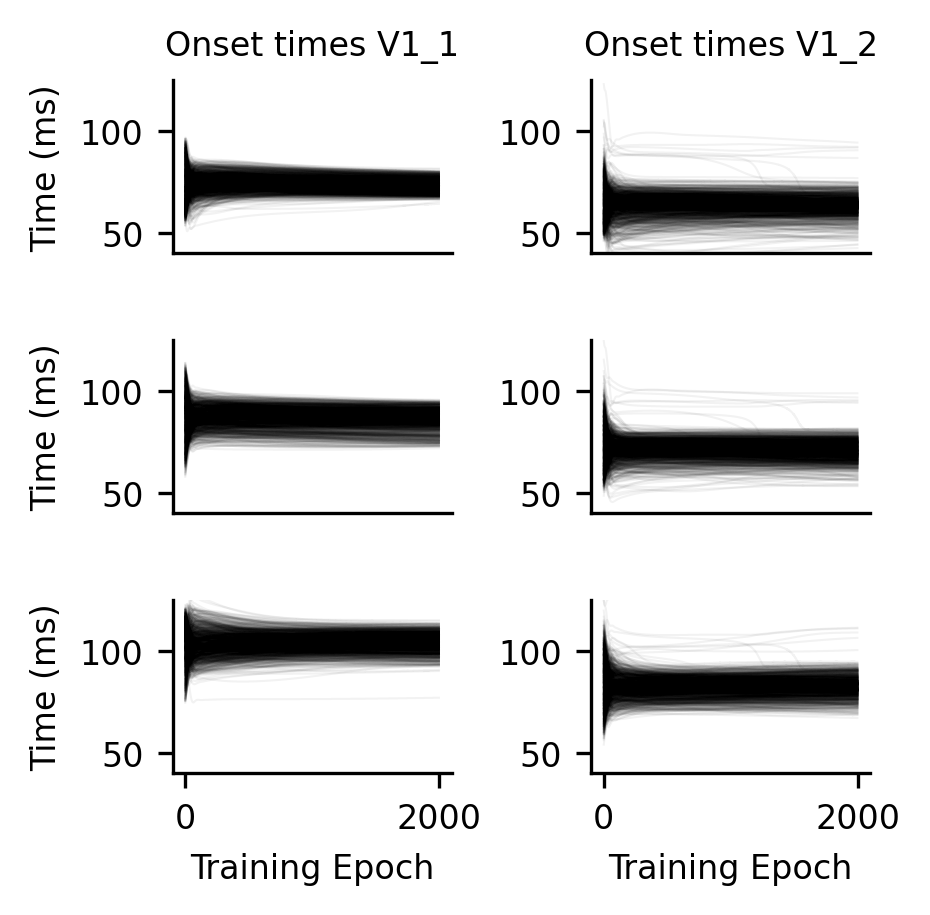

In [24]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 1

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Onset times V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['t'][0], param_bounds['t'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_t_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

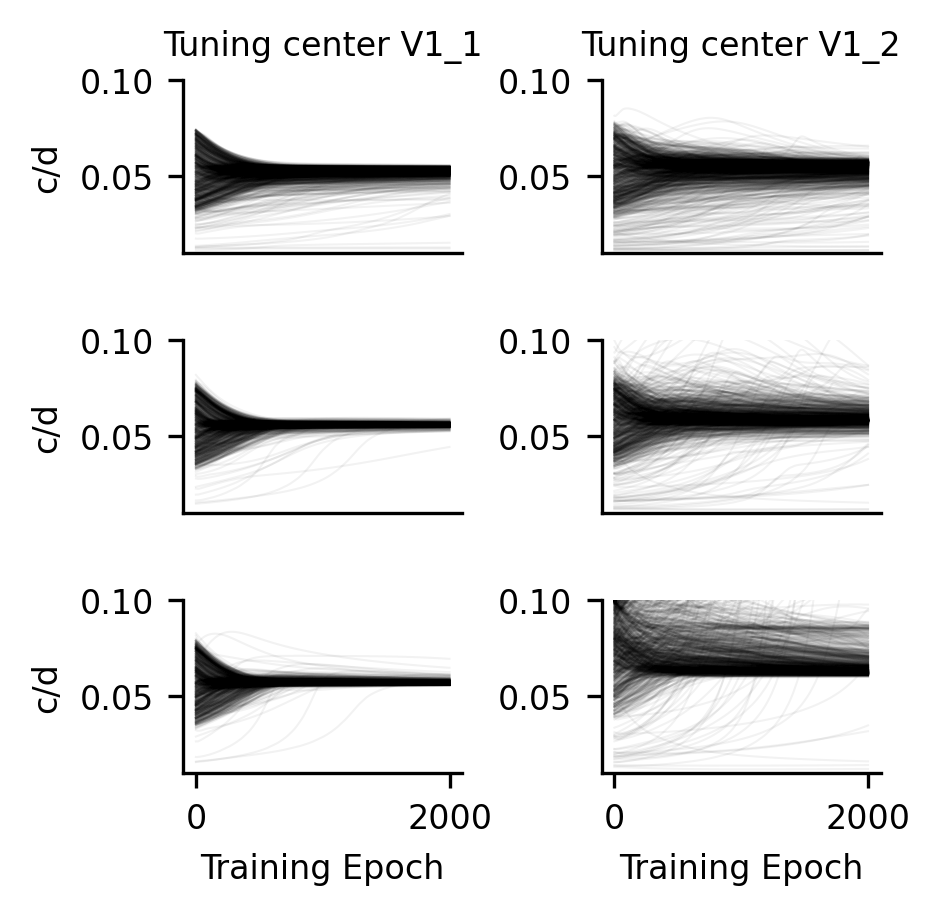

In [25]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 2

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning center V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("c/d", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampc'][0], param_bounds['ampc'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampc_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

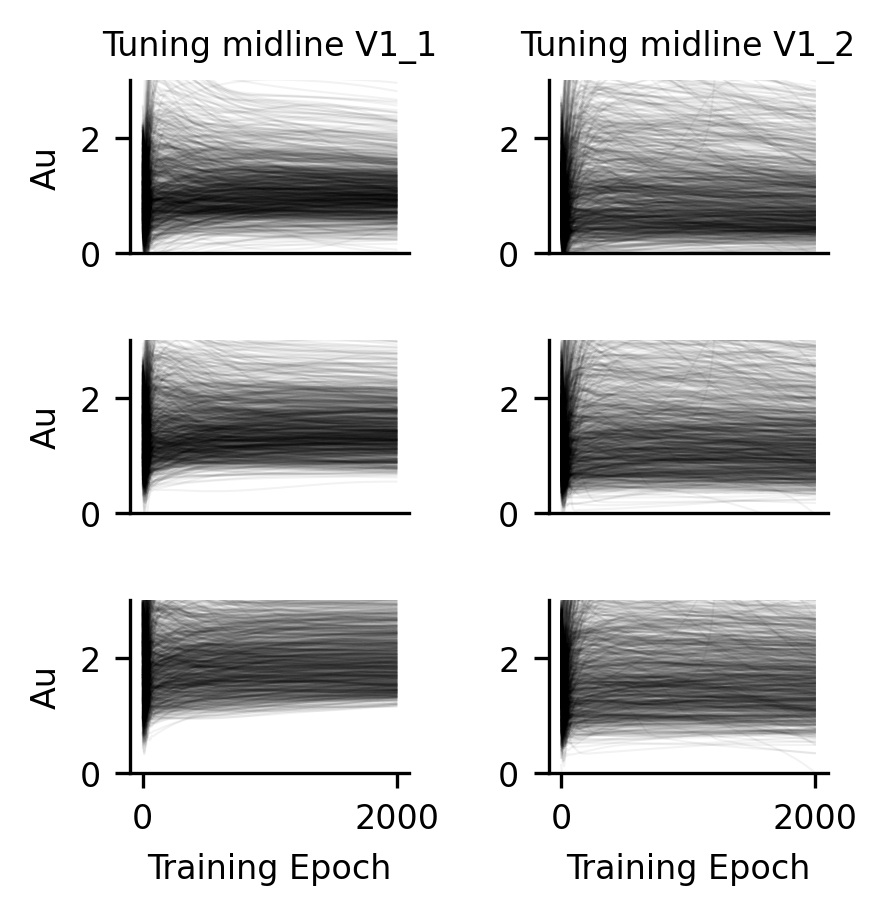

In [26]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 3

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning midline V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampm'][0], param_bounds['ampm'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampm_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

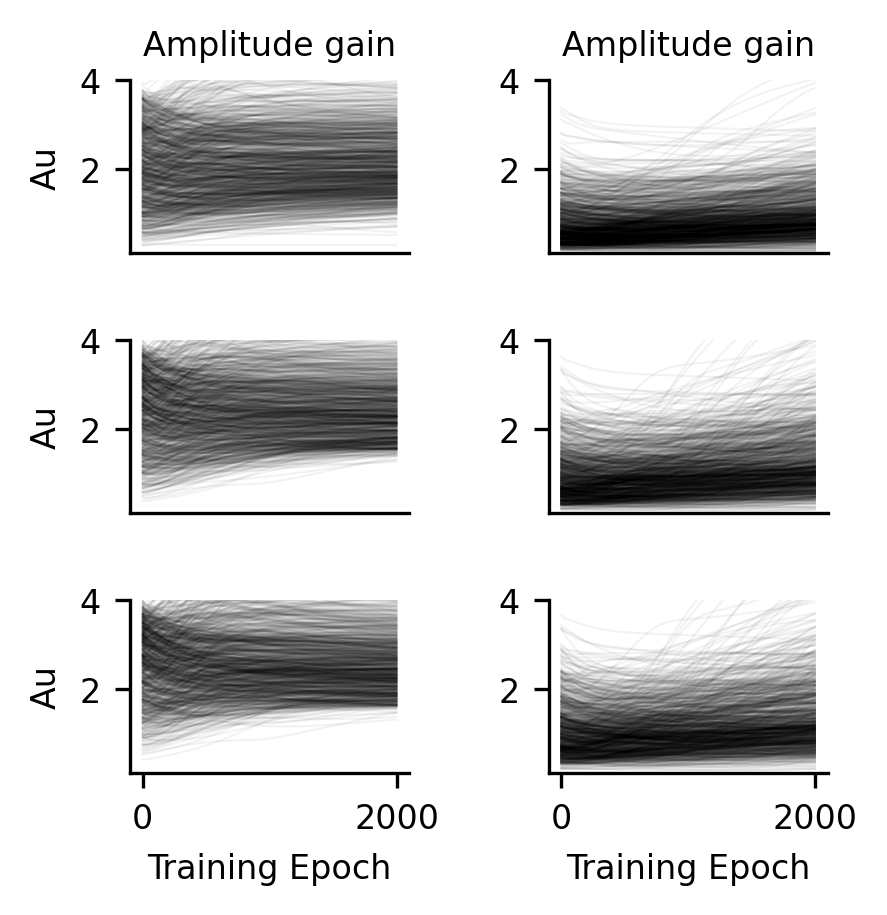

In [27]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 4

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Amplitude gain", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampg'][0], param_bounds['ampg'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampg_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

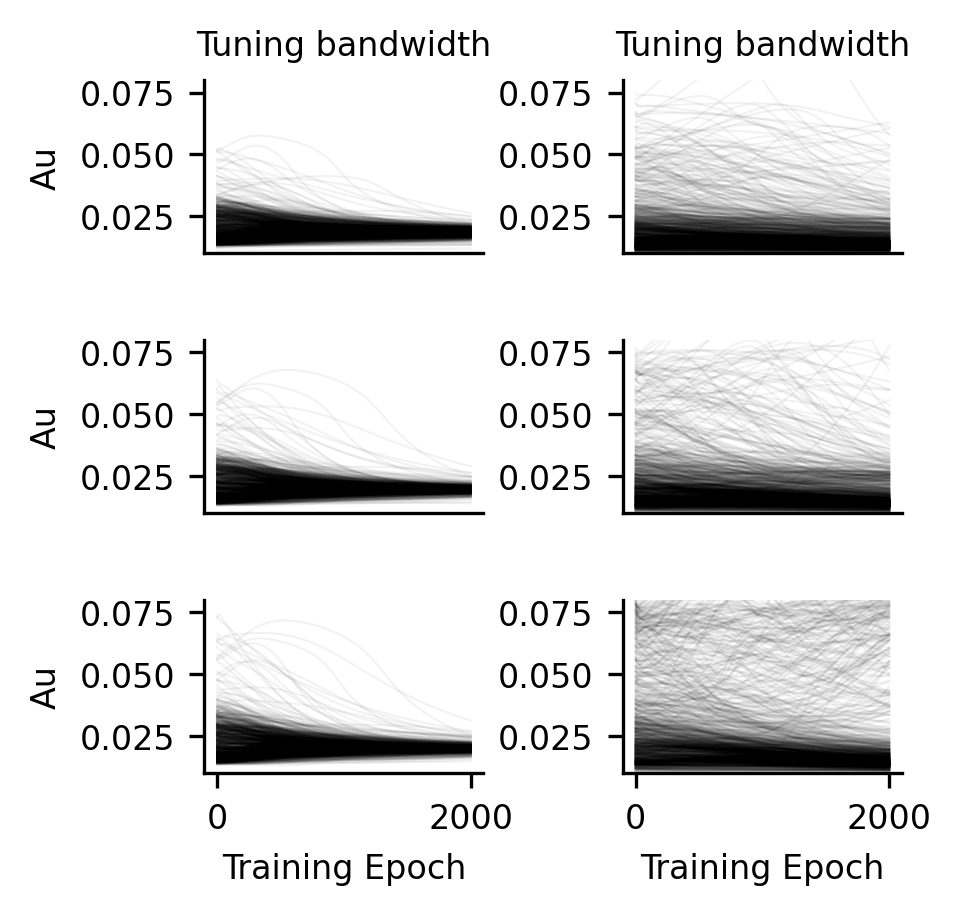

In [28]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 5

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning bandwidth", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['ampw'][0], param_bounds['ampw'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_ampw_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

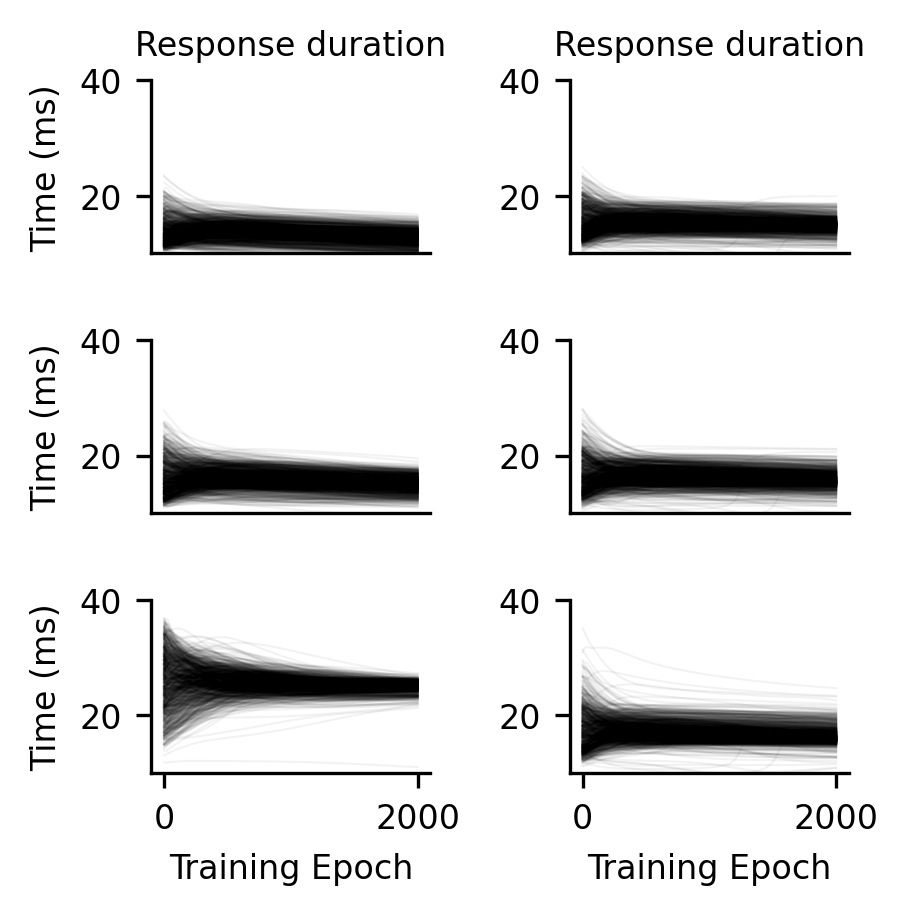

In [29]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 6

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Response duration", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(param_bounds['d'][0], param_bounds['d'][1])
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

# figname = '2d_model_d_convergence_first_round.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [30]:
res = param_history['dLGN_params'].squeeze()
print(res.shape[2:])
n_samples, n_epochs = res.shape[:2]
n_params = np.prod(res.shape[2:])# + np.prod(r2.shape[2:])

res = res.reshape(res.shape[0] * res.shape[1], np.prod(res.shape[2:]))

(2, 3, 7)


In [31]:
pca = PCA() # all epochs included
res_transformed_pca = pca.fit_transform(res).reshape(n_samples, n_epochs, n_params)

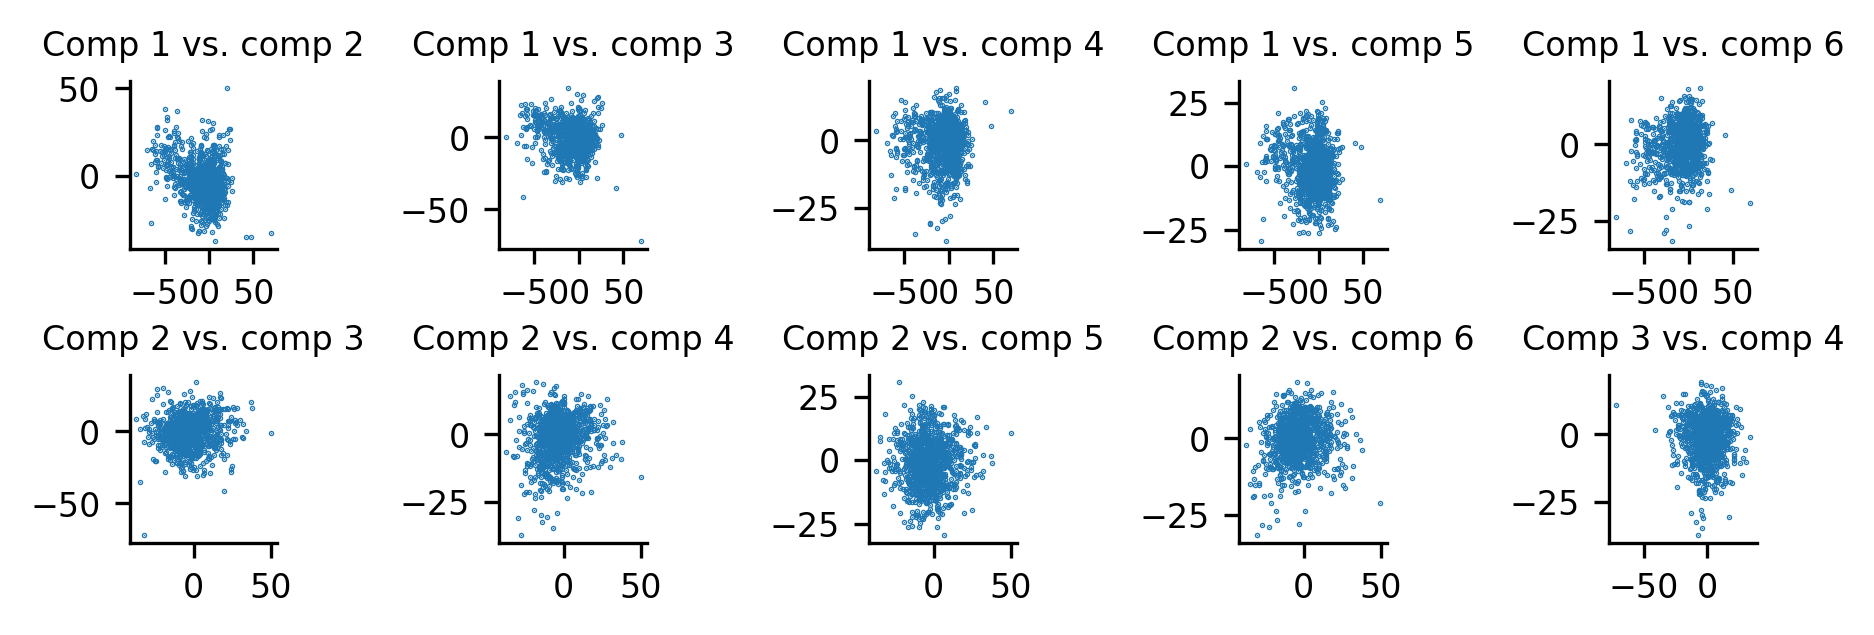

In [32]:
fig, ax = plt.subplots(2,5, figsize = (7,2))

comp_pairs = (list(combinations(np.arange(6), 2)))
i = 0
for row in range(2):
    for col in range(5):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        c0, c1 = comp_pairs[i]
        ax[row, col].scatter(res_transformed_pca[:,-1,c0], res_transformed_pca[:,-1,c1], s = 0.1) # last epoch
        ax[row, col].set_title(f"Comp {c0+1} vs. comp {c1+1}", fontsize = fontsize)
        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = 1.5)
figname = '2d_model_pcaprojection_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [33]:
lgn_params = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

v1_params = [
    'Inhibition delay',
    'Inhibition weight'
]

lgn_units = [
    'dLGN_1 into V1_1',
    'dLGN_2 into V1_1',
    'dLGN_3 into V1_1',
    'dLGN_1 into V1_2',
    'dLGN_2 into V1_2',
    'dLGN_3 into V1_2',
]

v1_units = [
    'V1_1',
    'V1_2'
]

full_lgn_params = []
for unit in lgn_units:
    for param in lgn_params:
        full_lgn_params.append(f"{param} ({unit})")

full_v1_params = []
for unit in v1_units:
    for param in v1_params:
        full_v1_params.append(f"{param} ({unit})")
        
param_names = full_lgn_params+full_v1_params

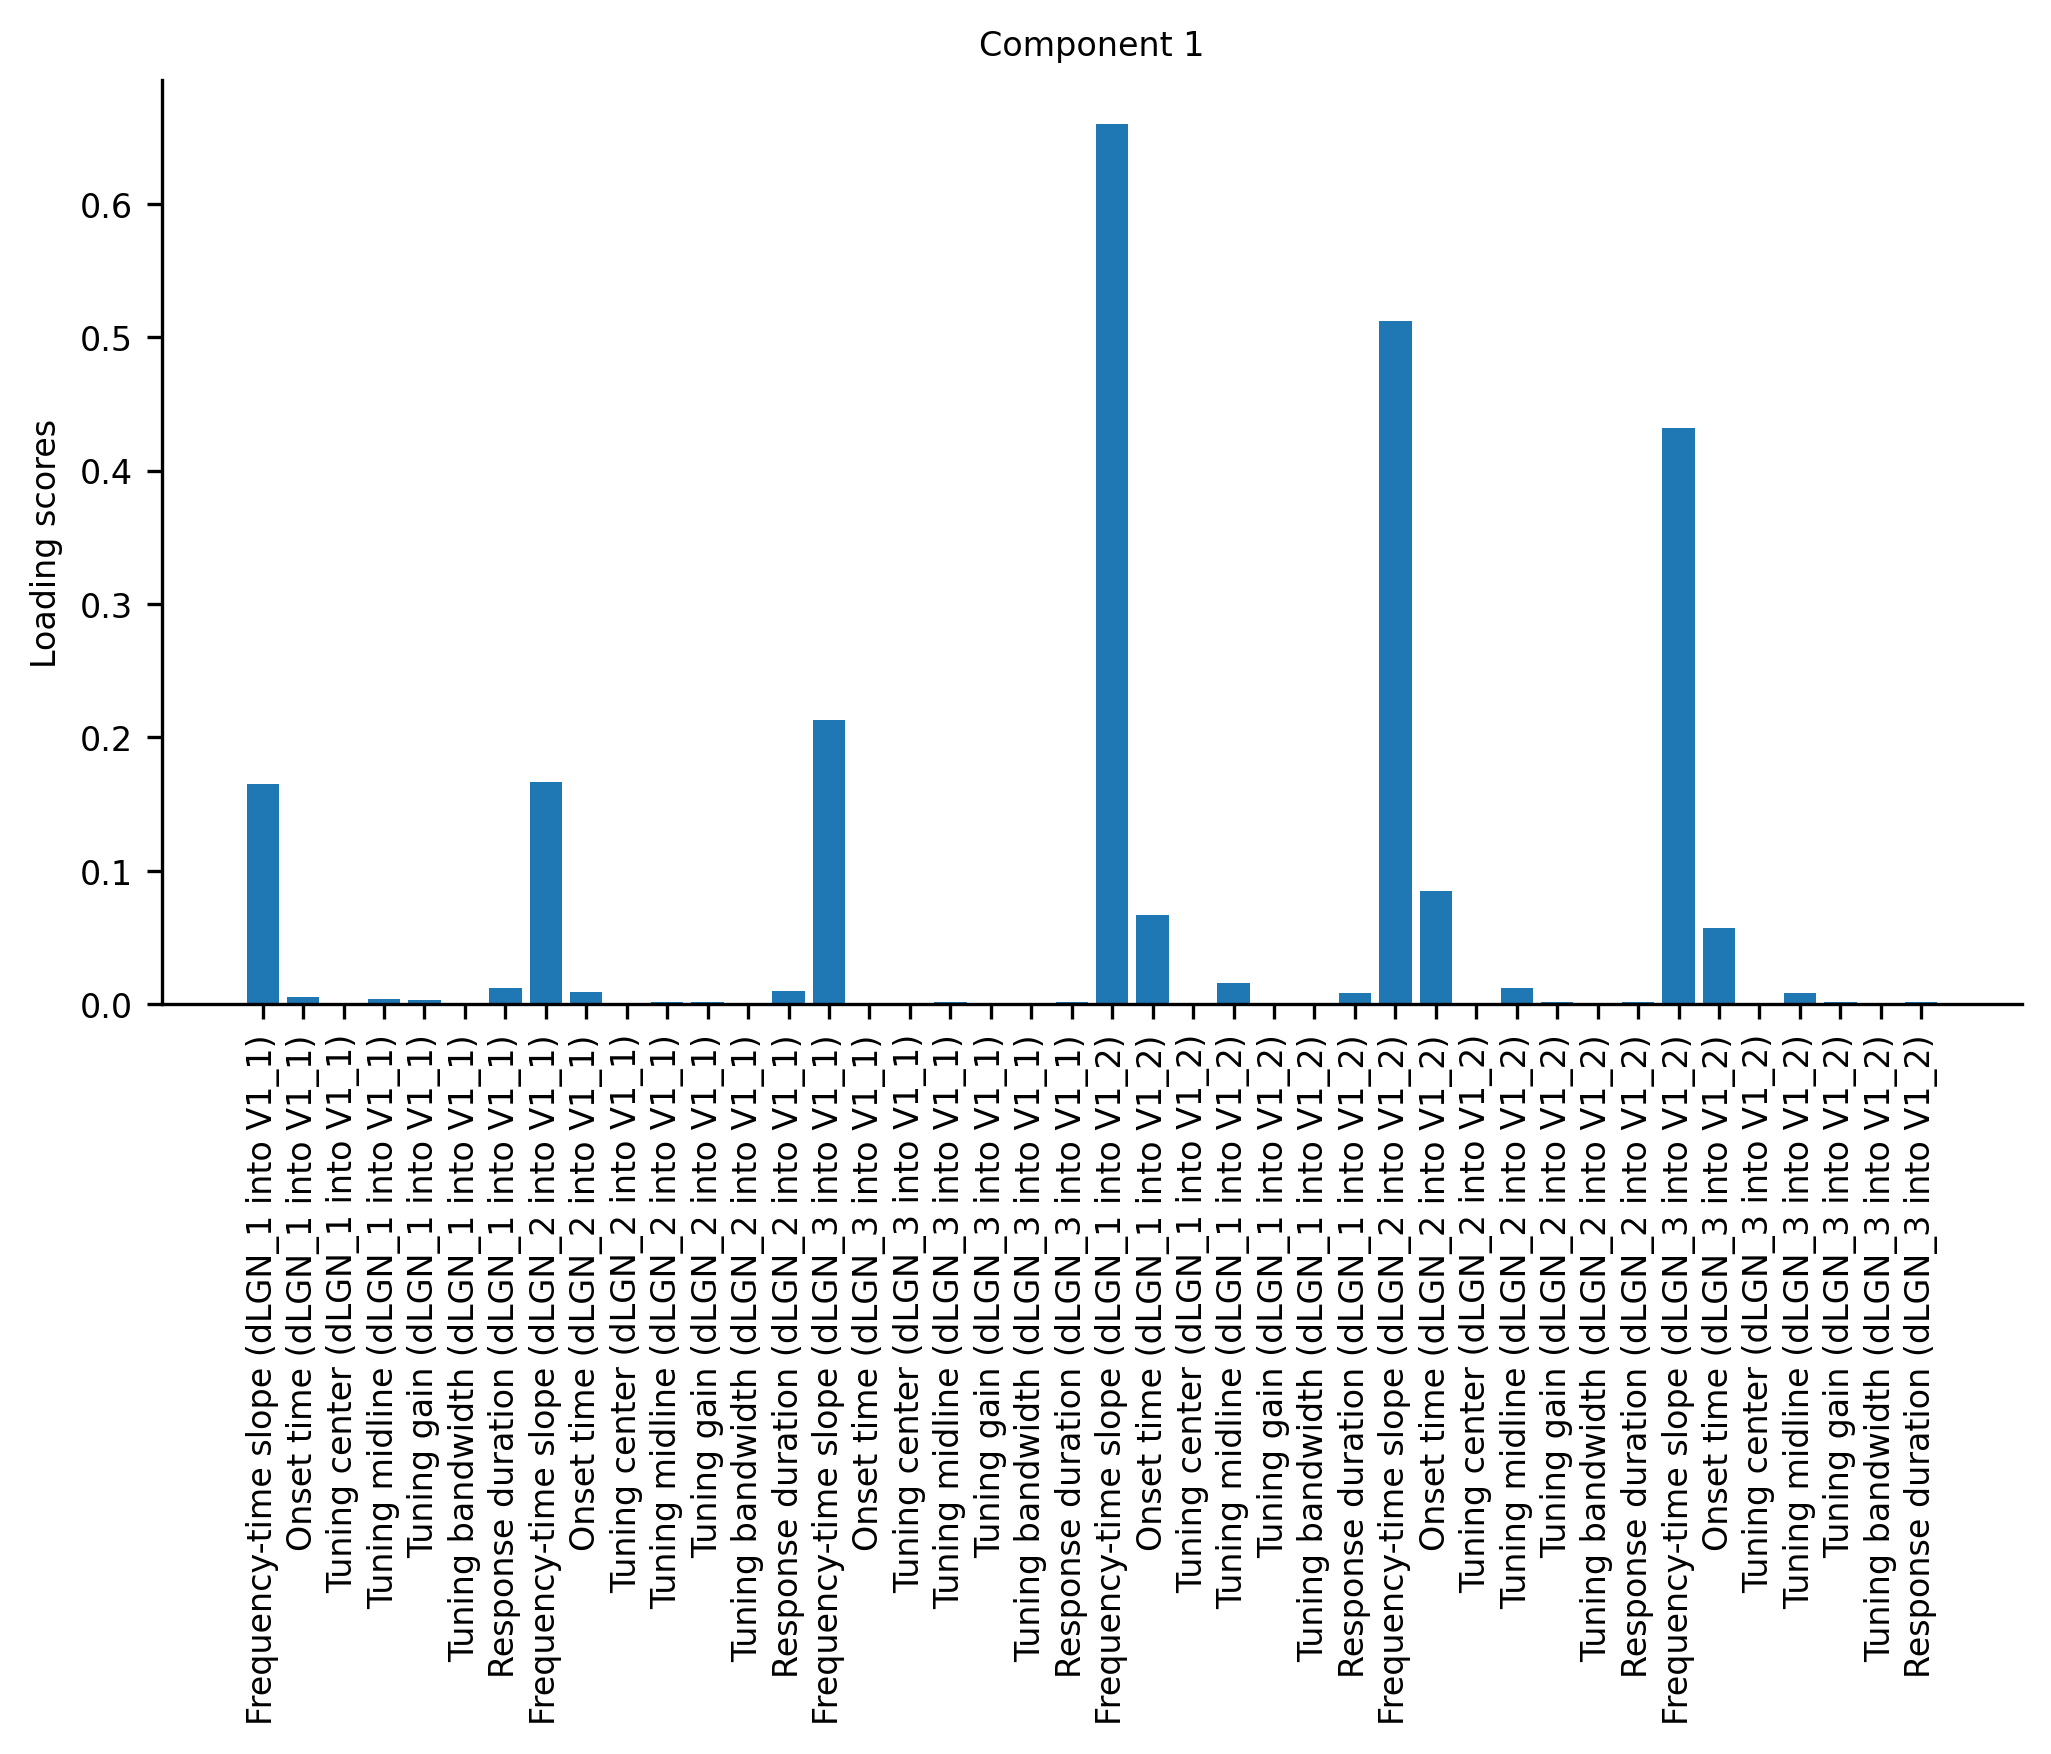

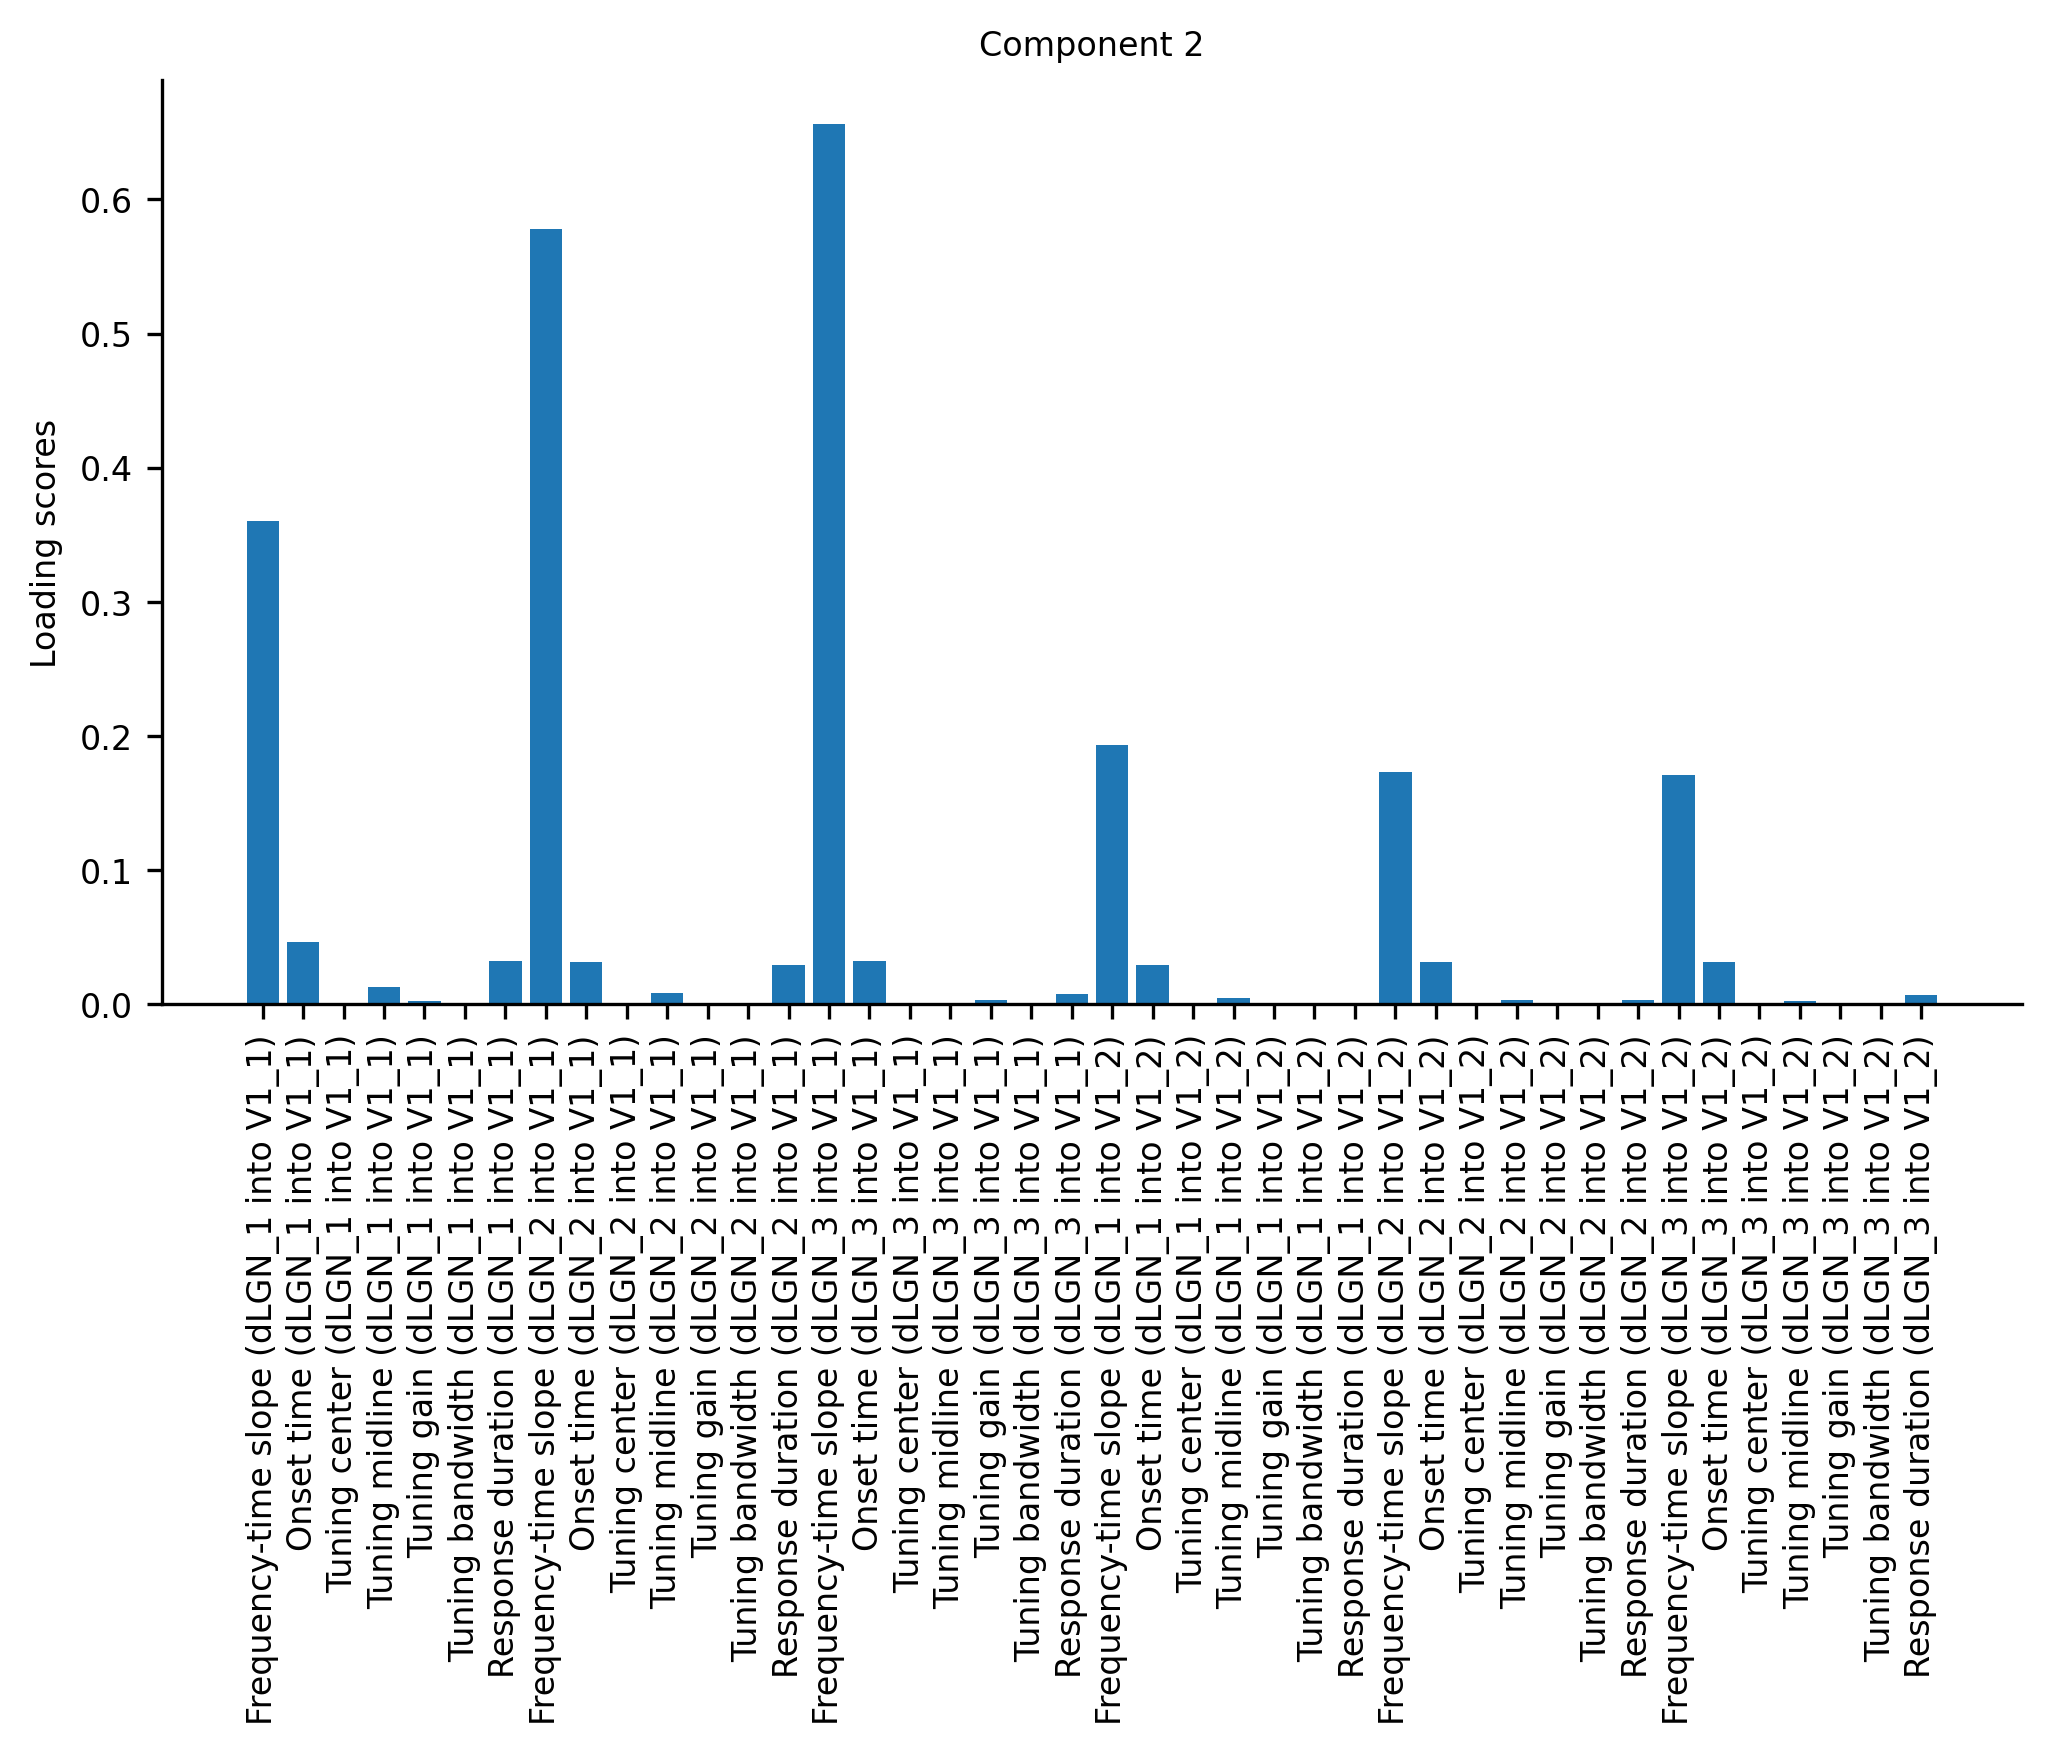

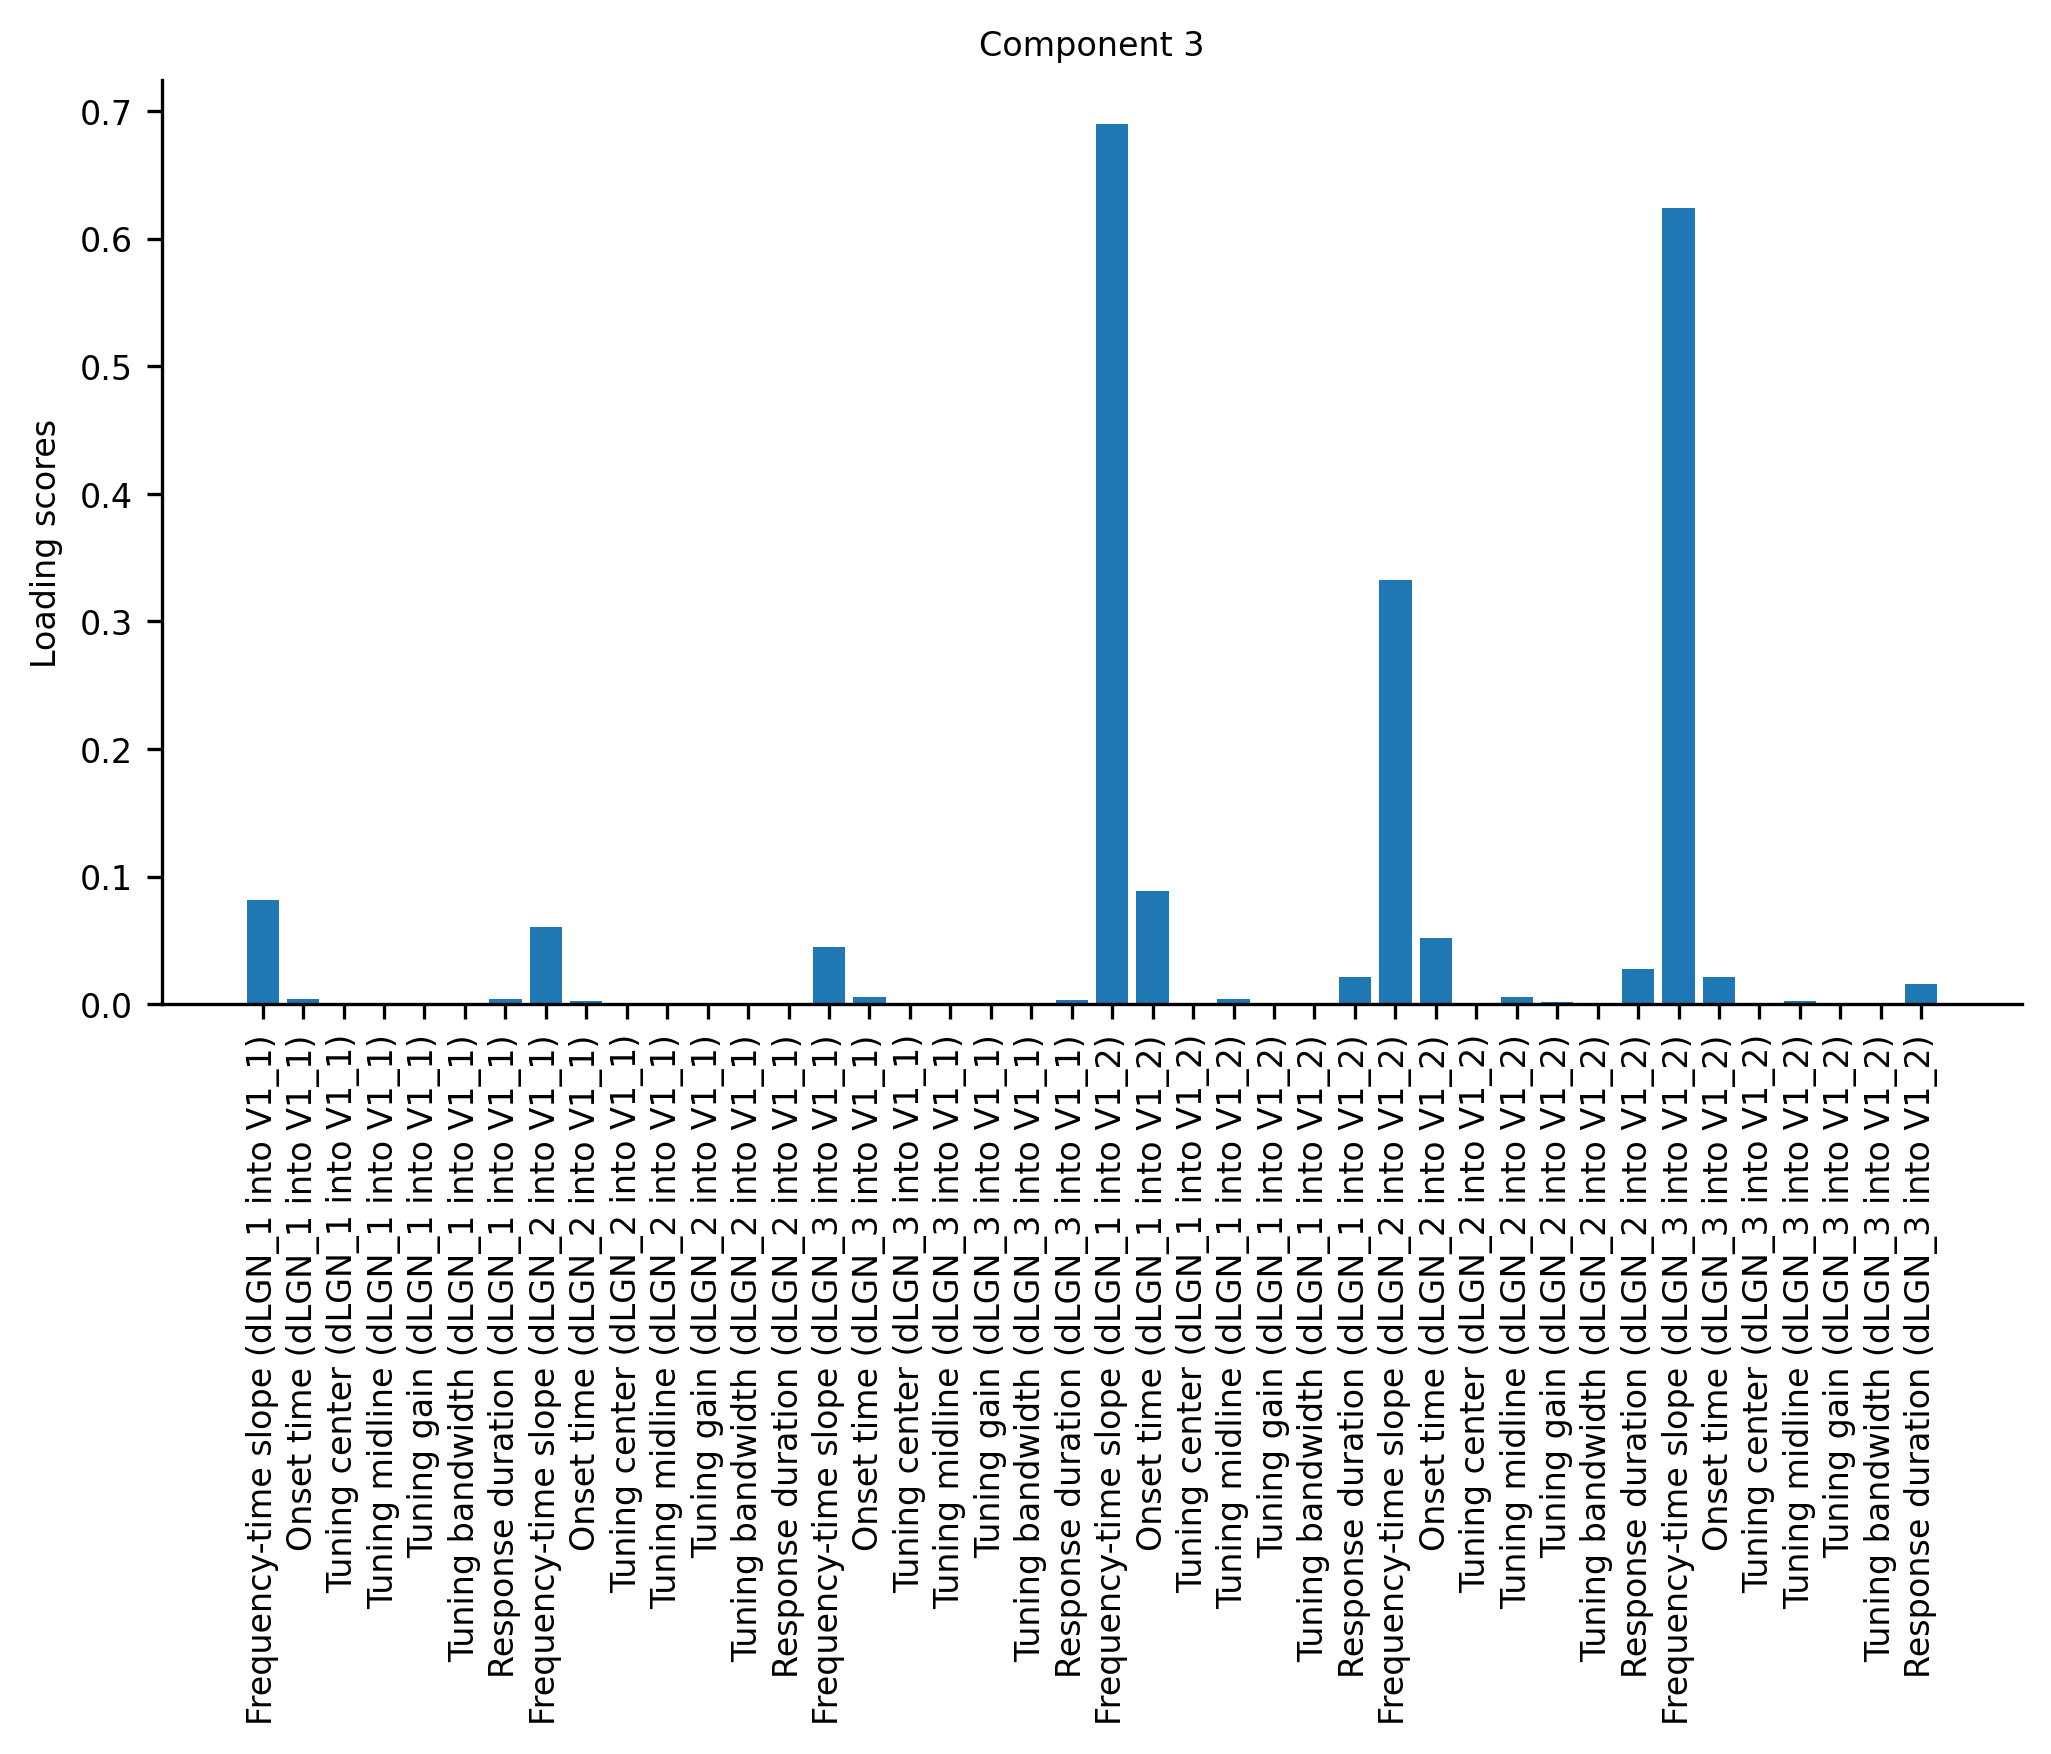

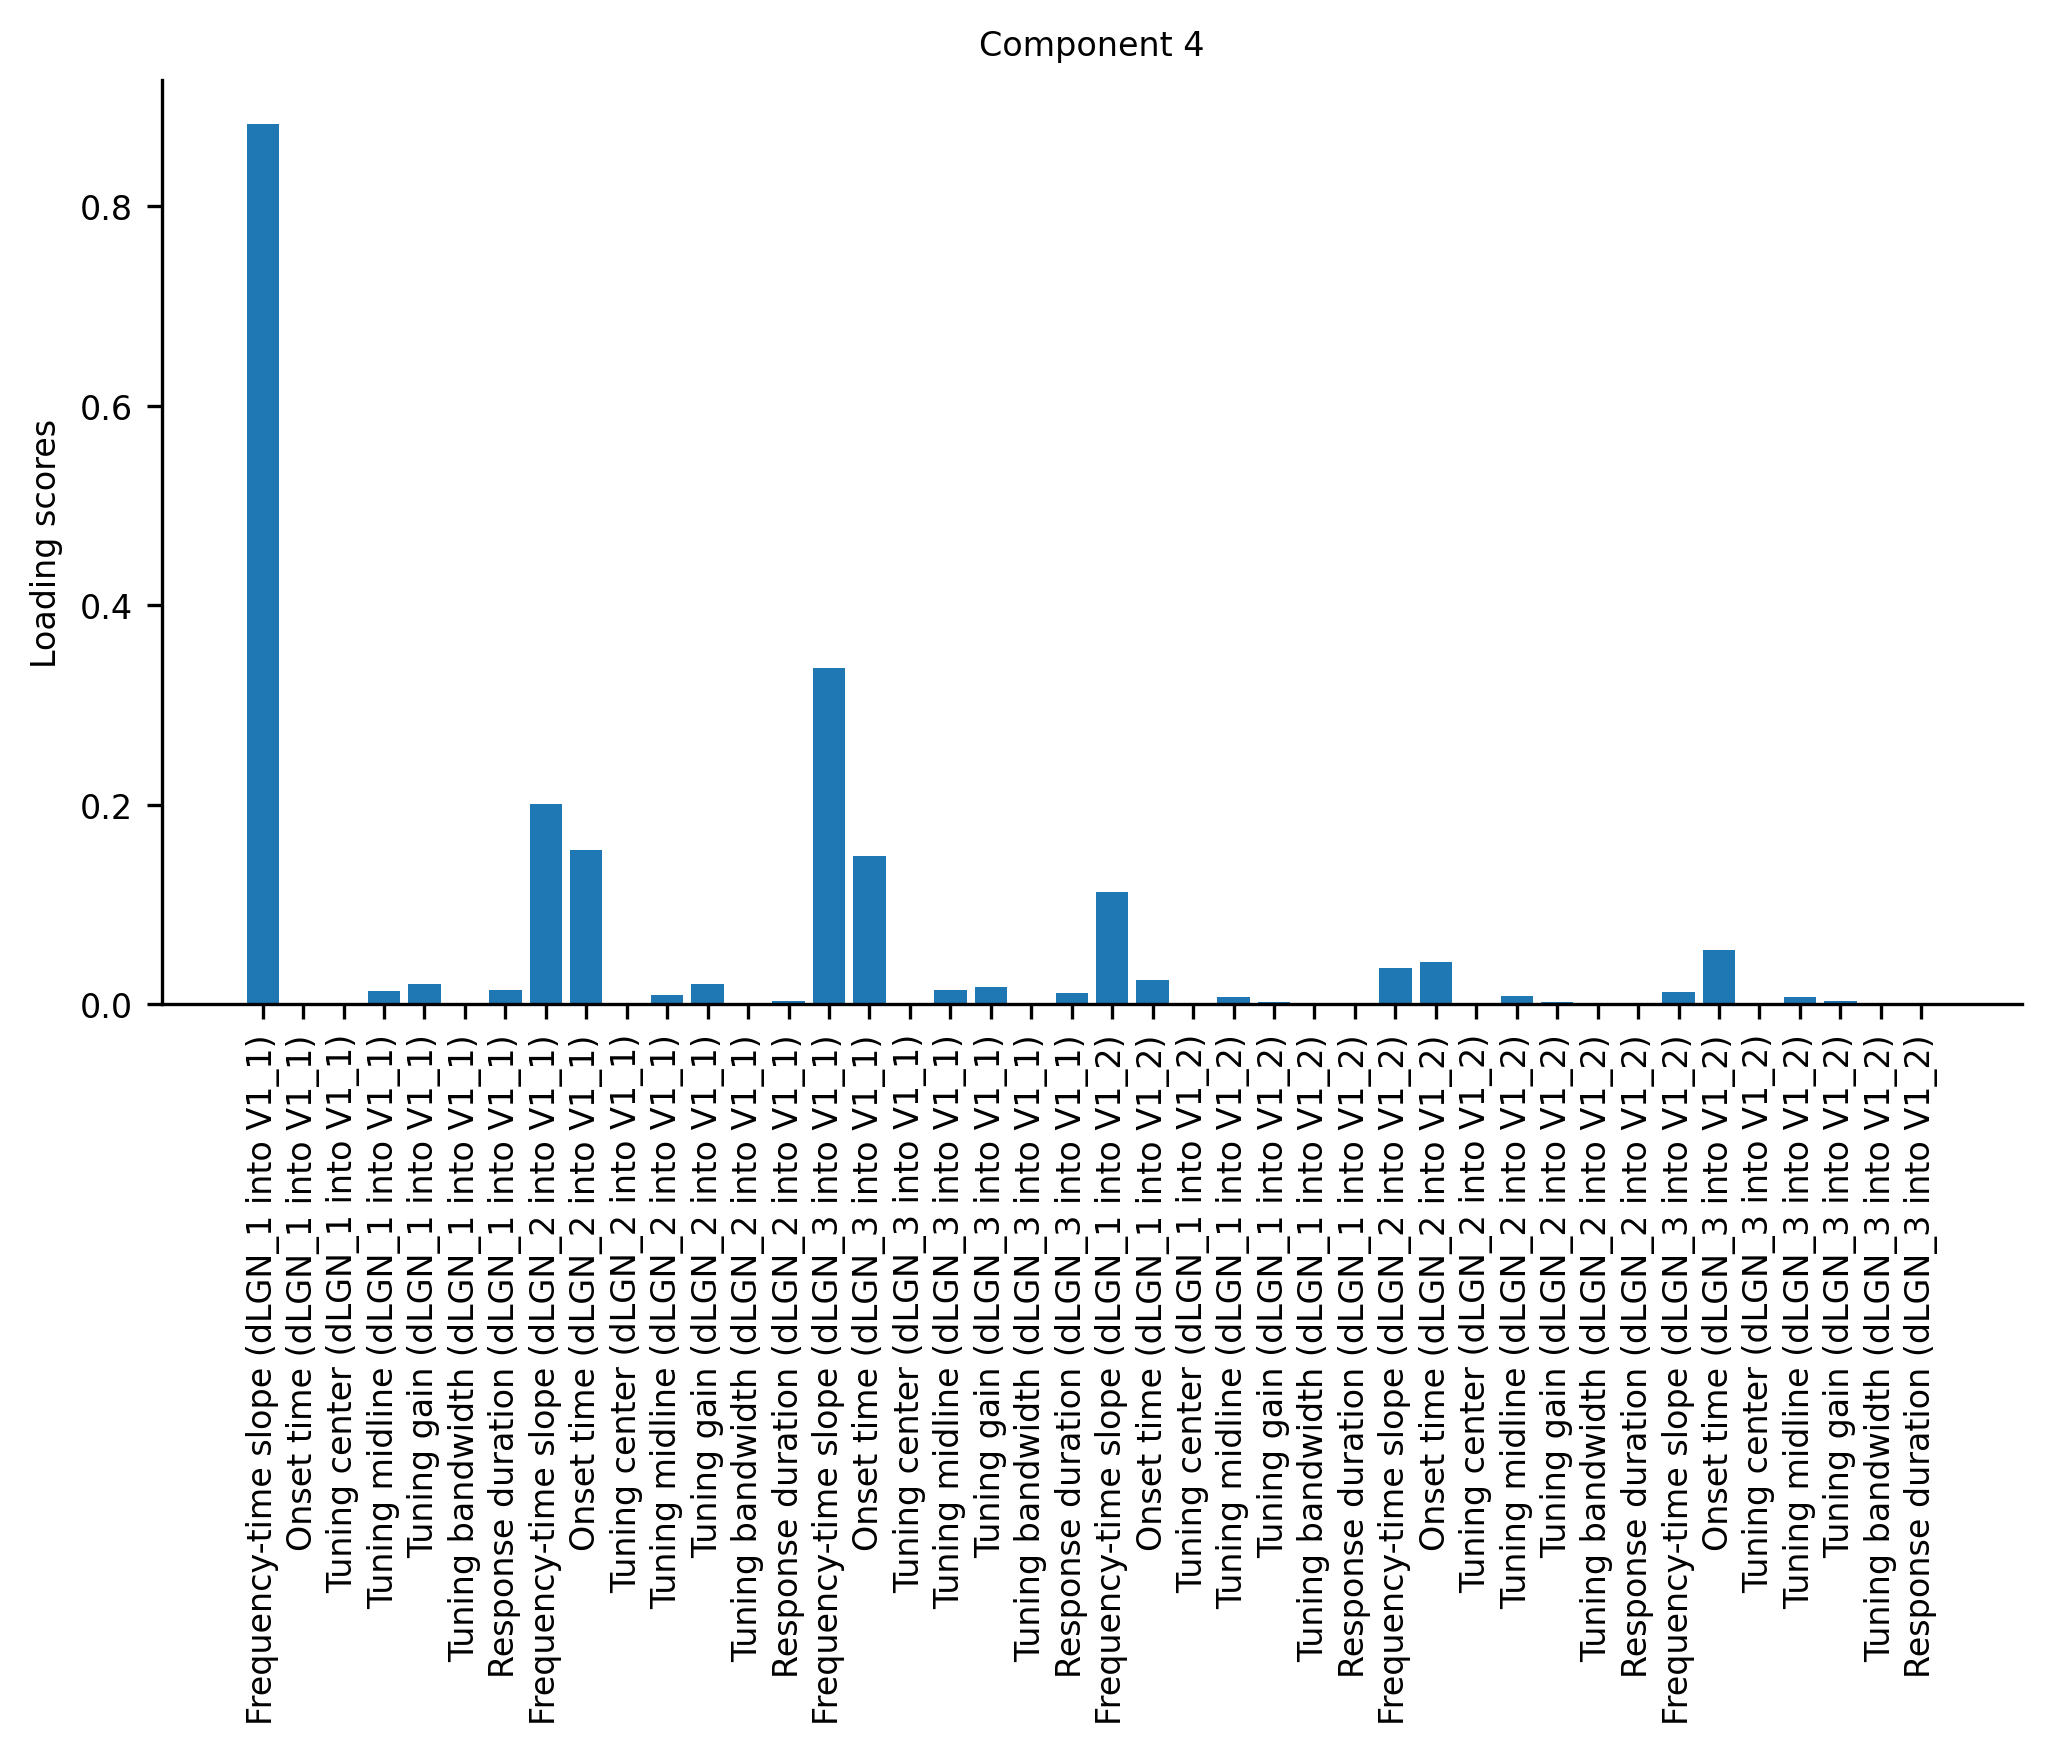

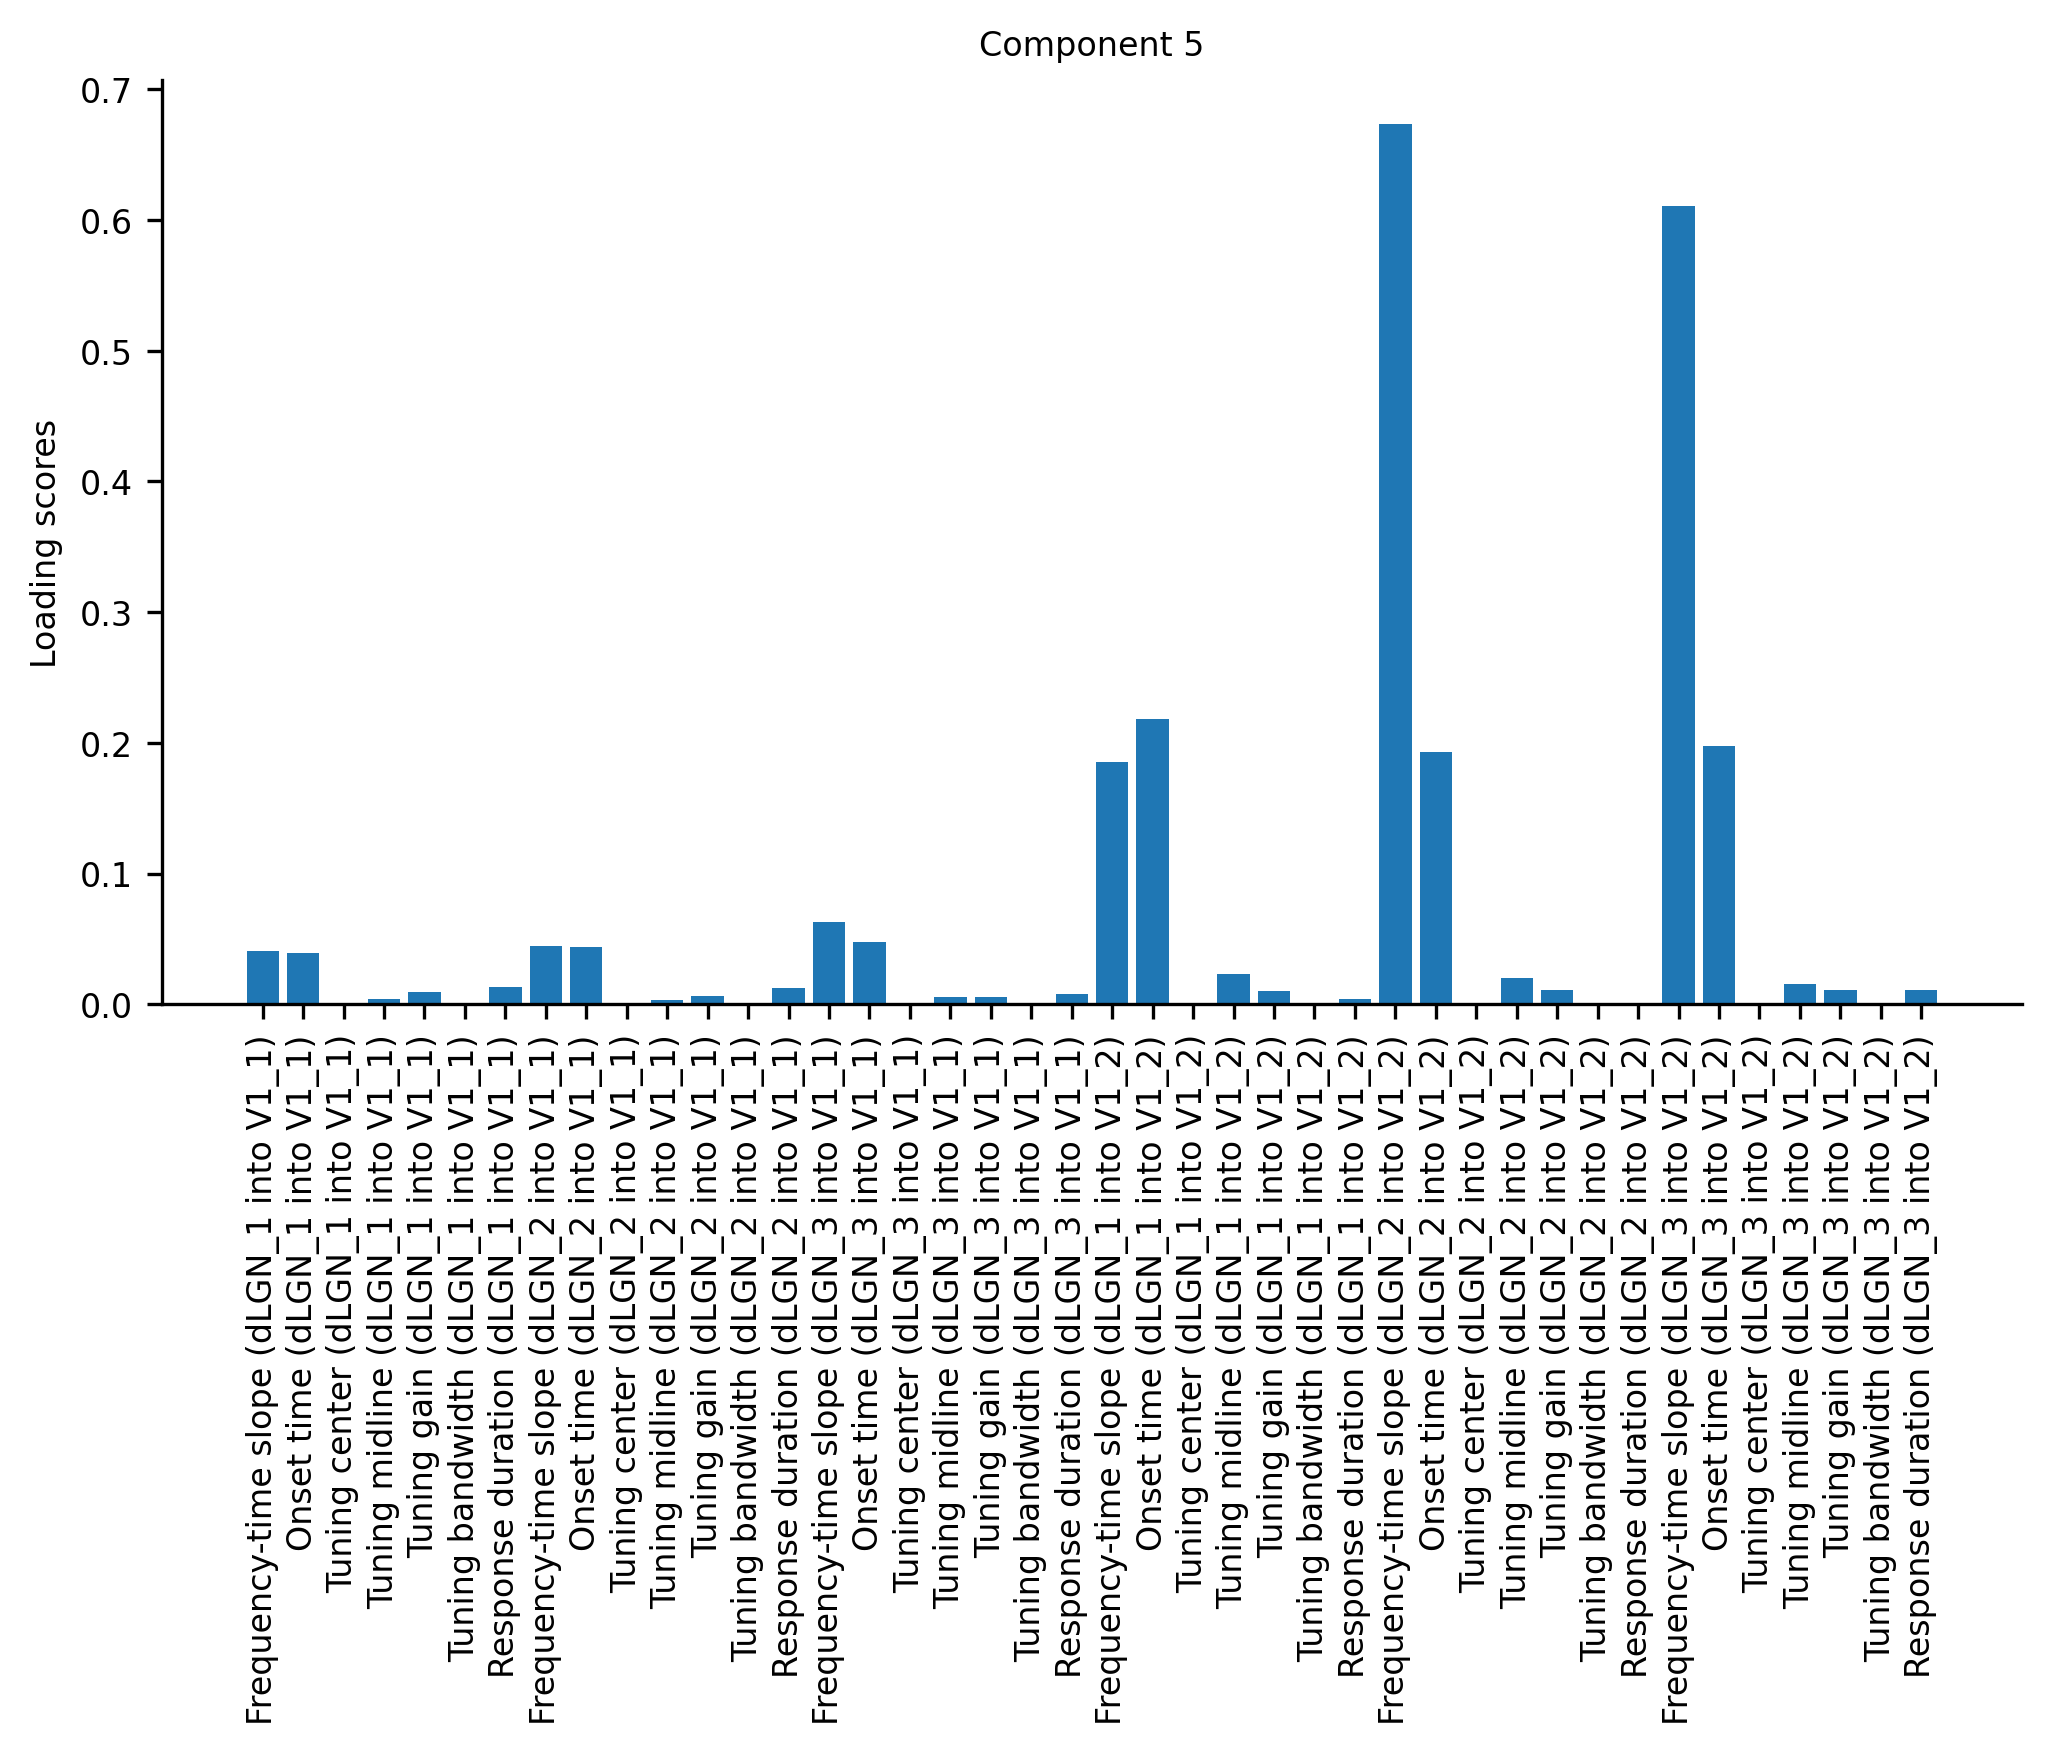

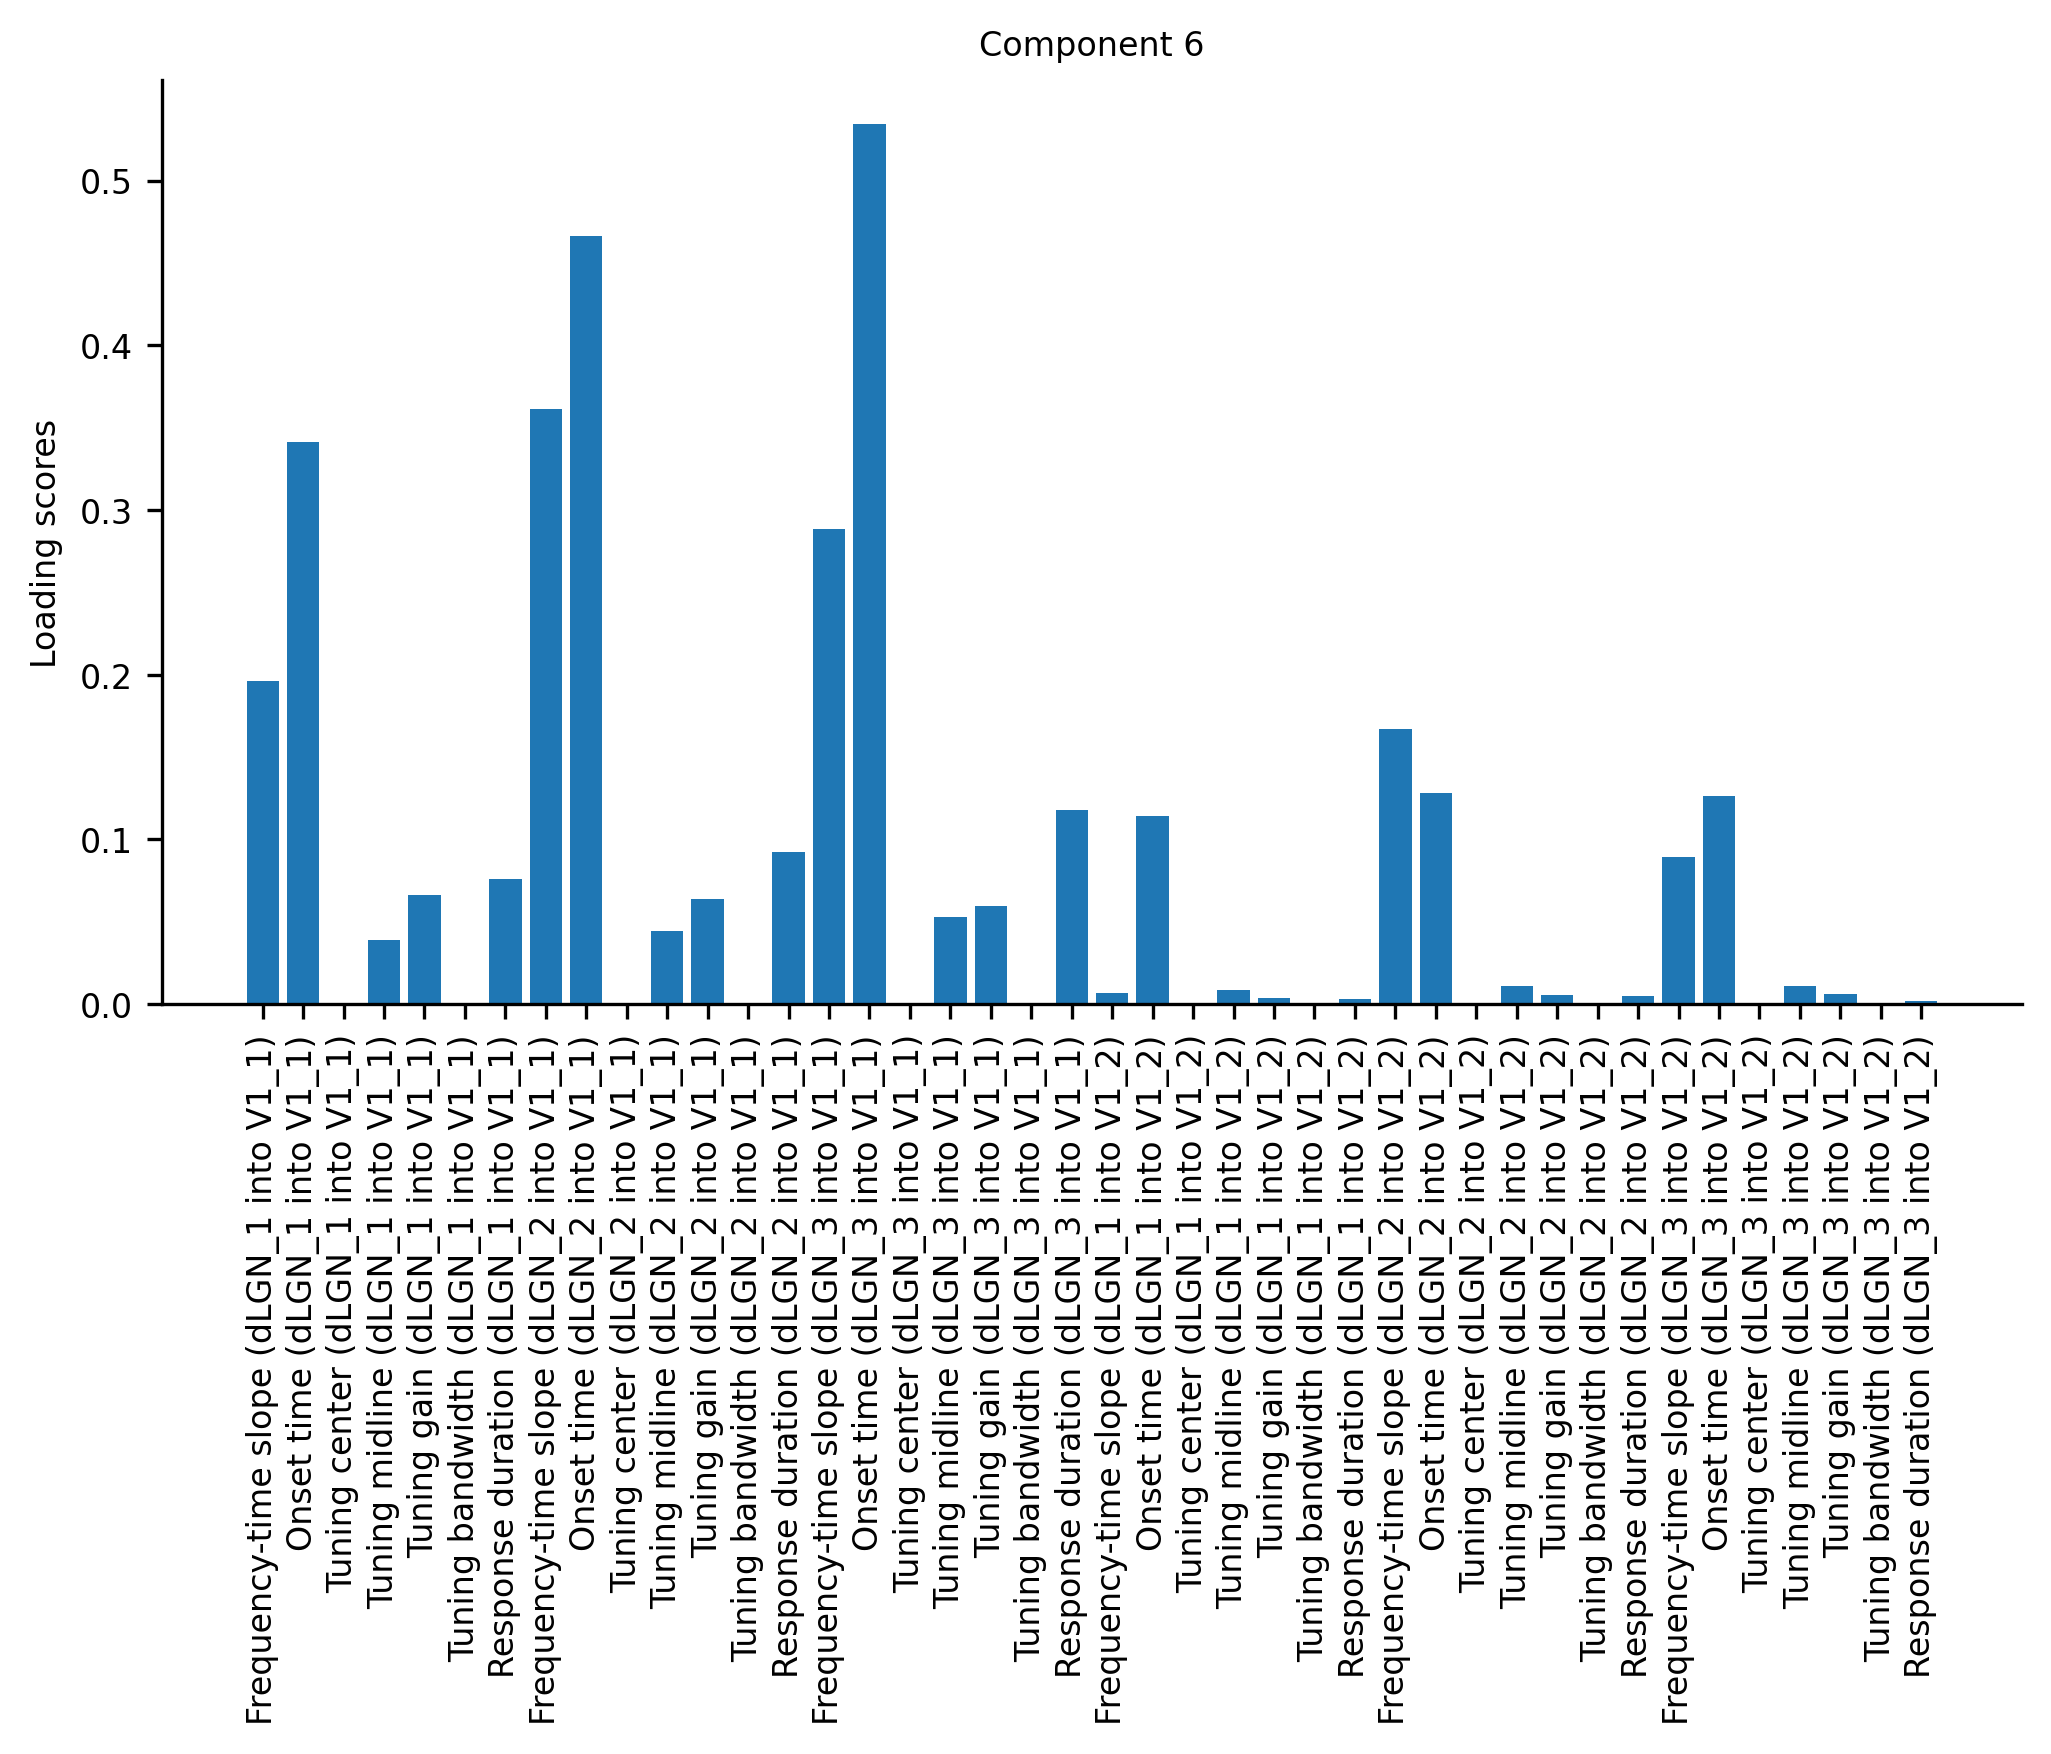

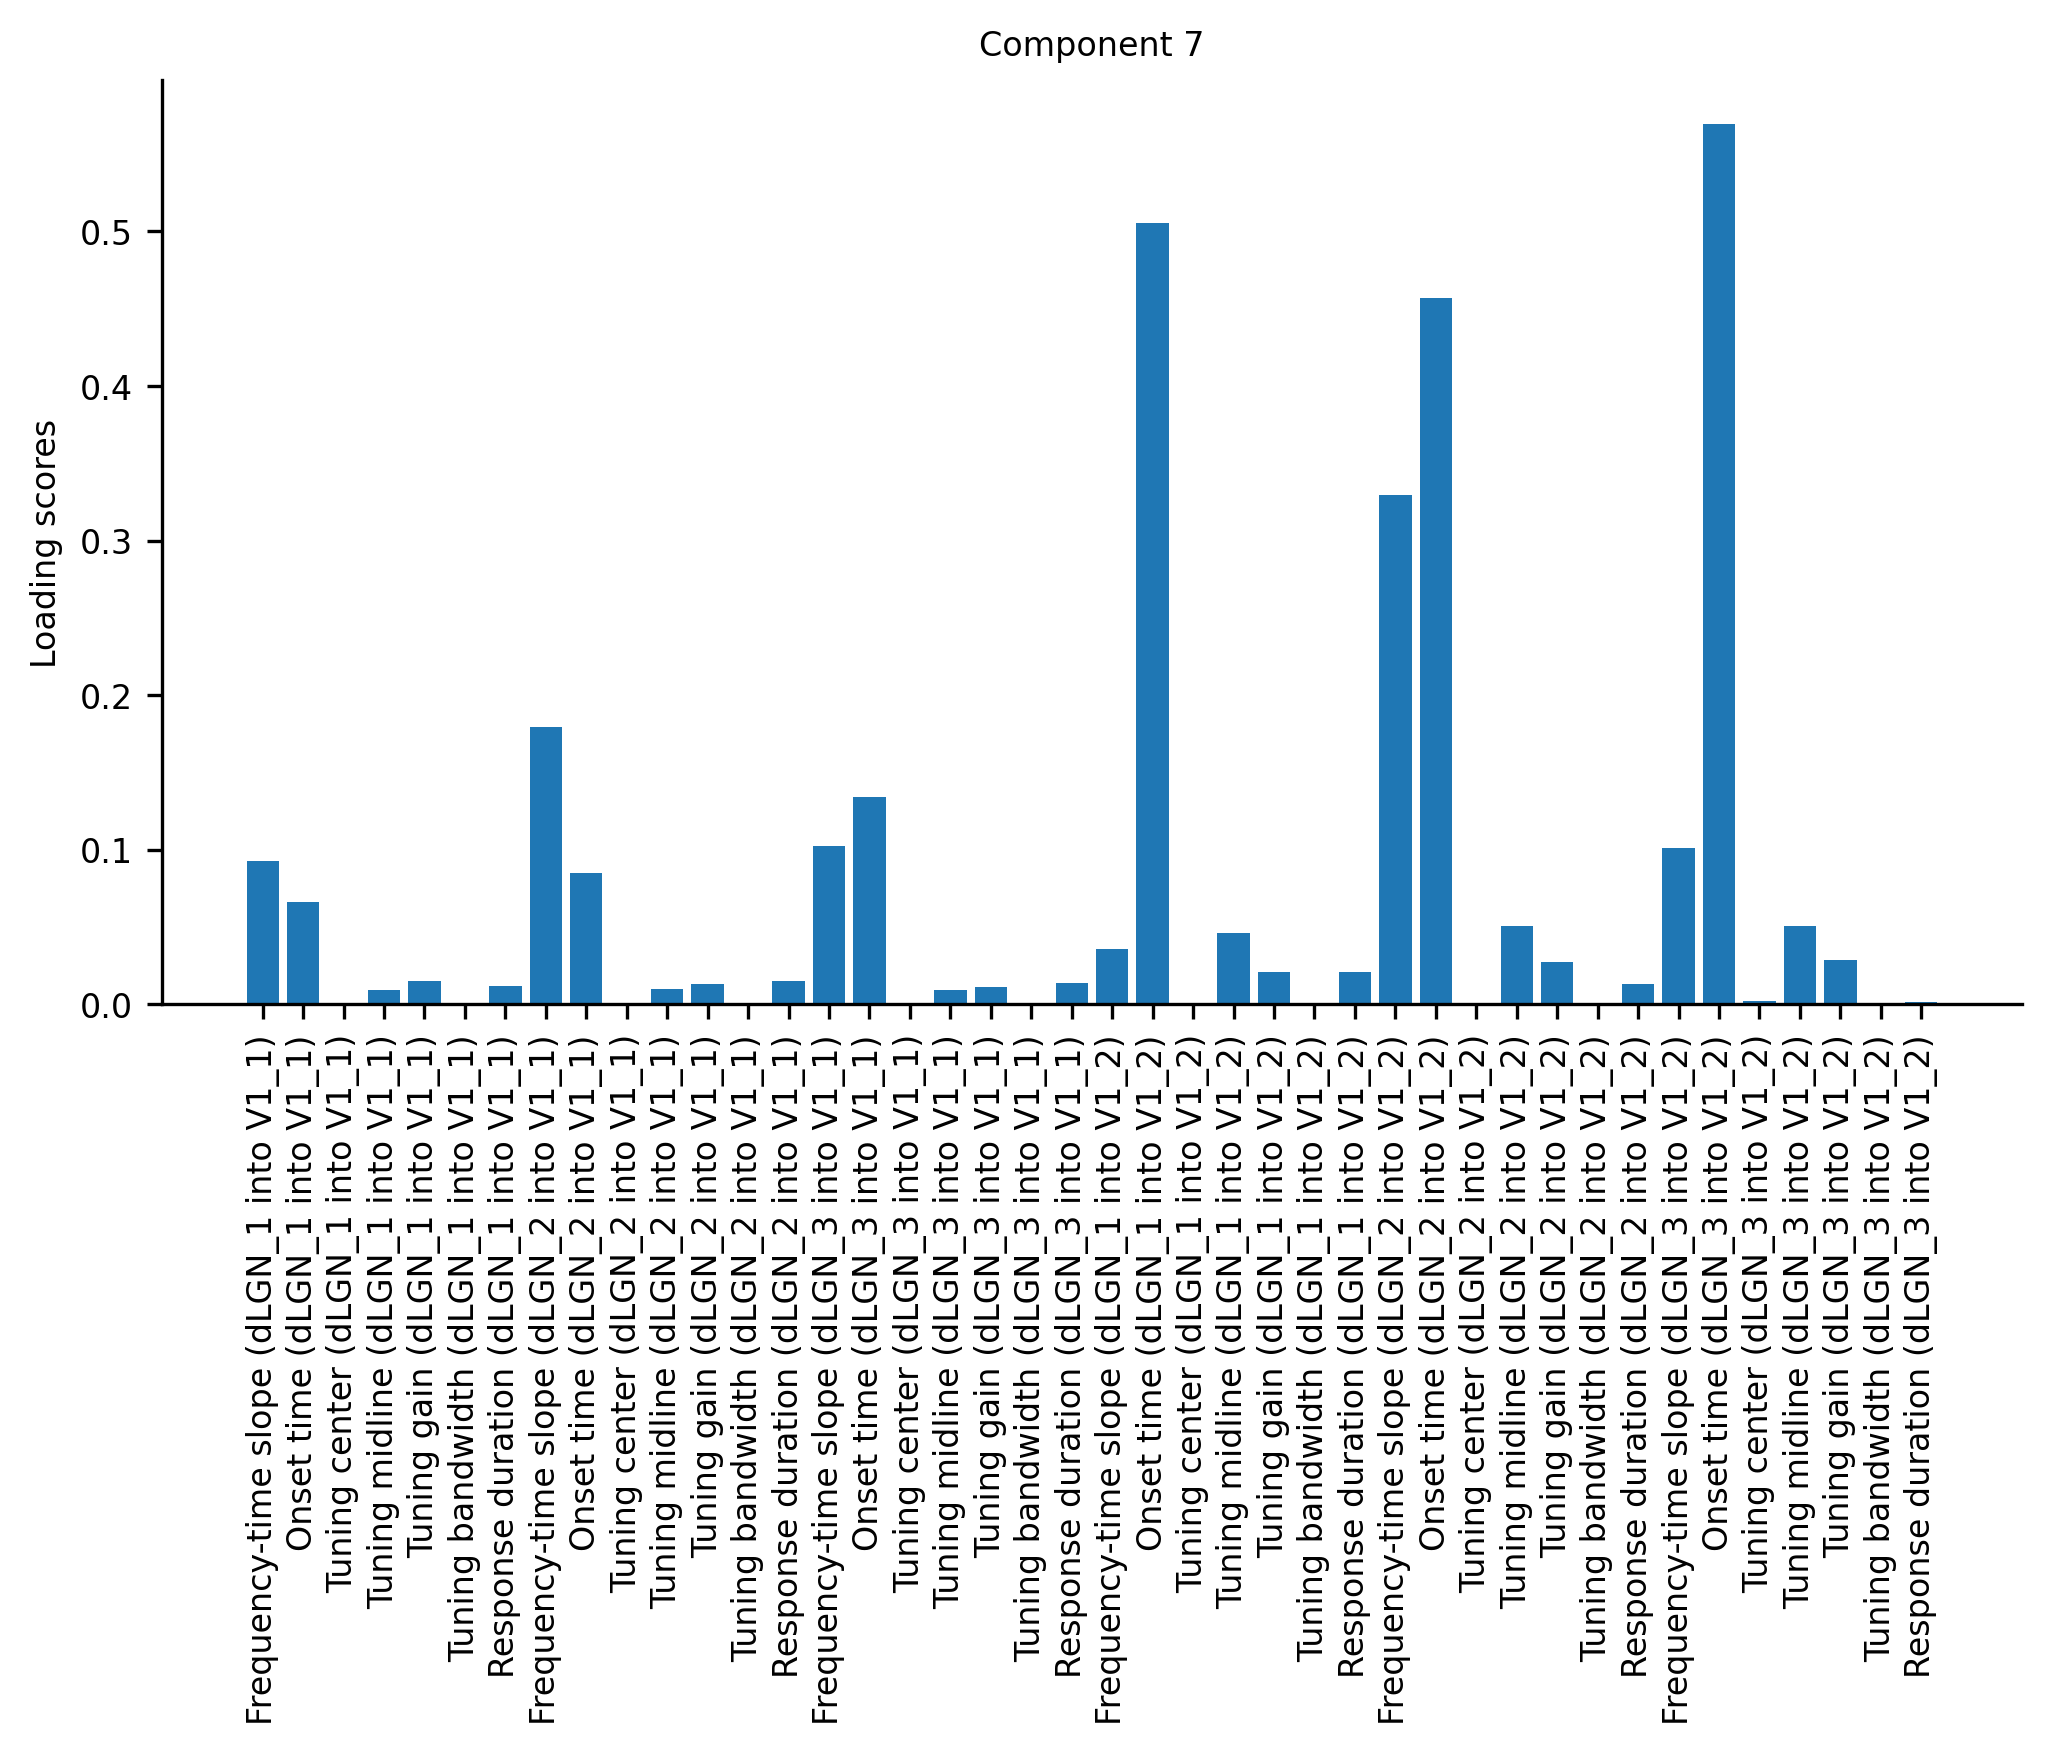

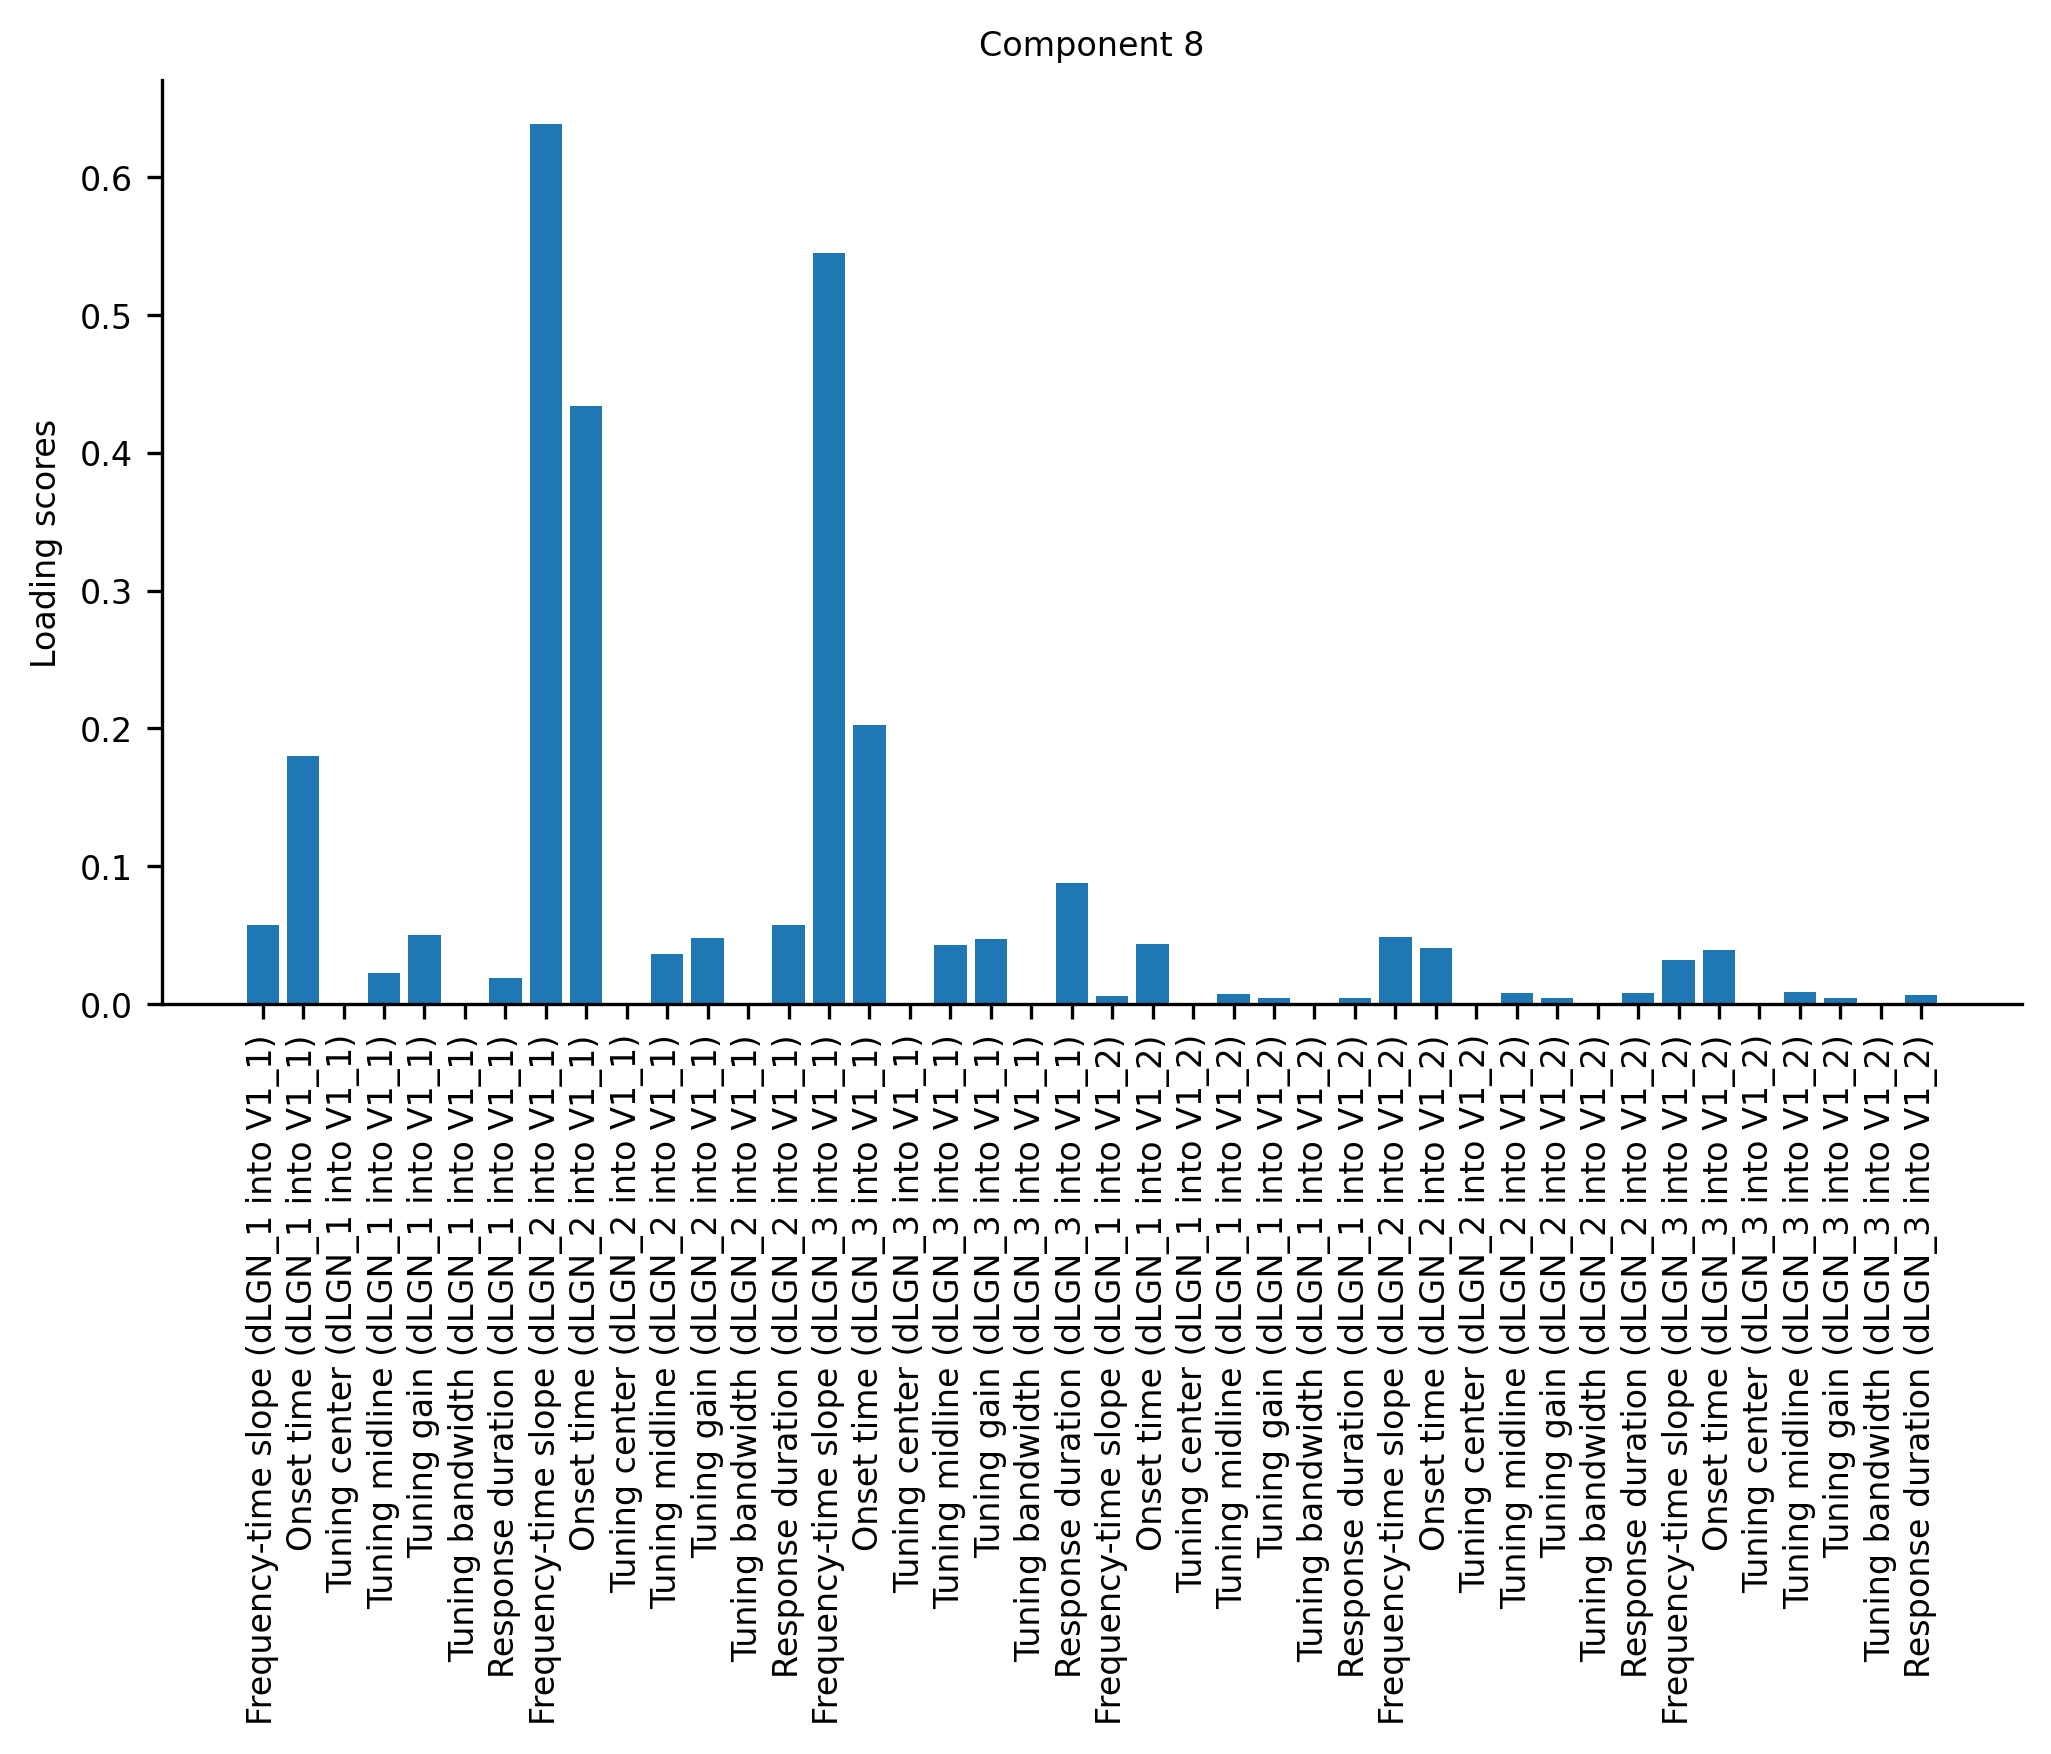

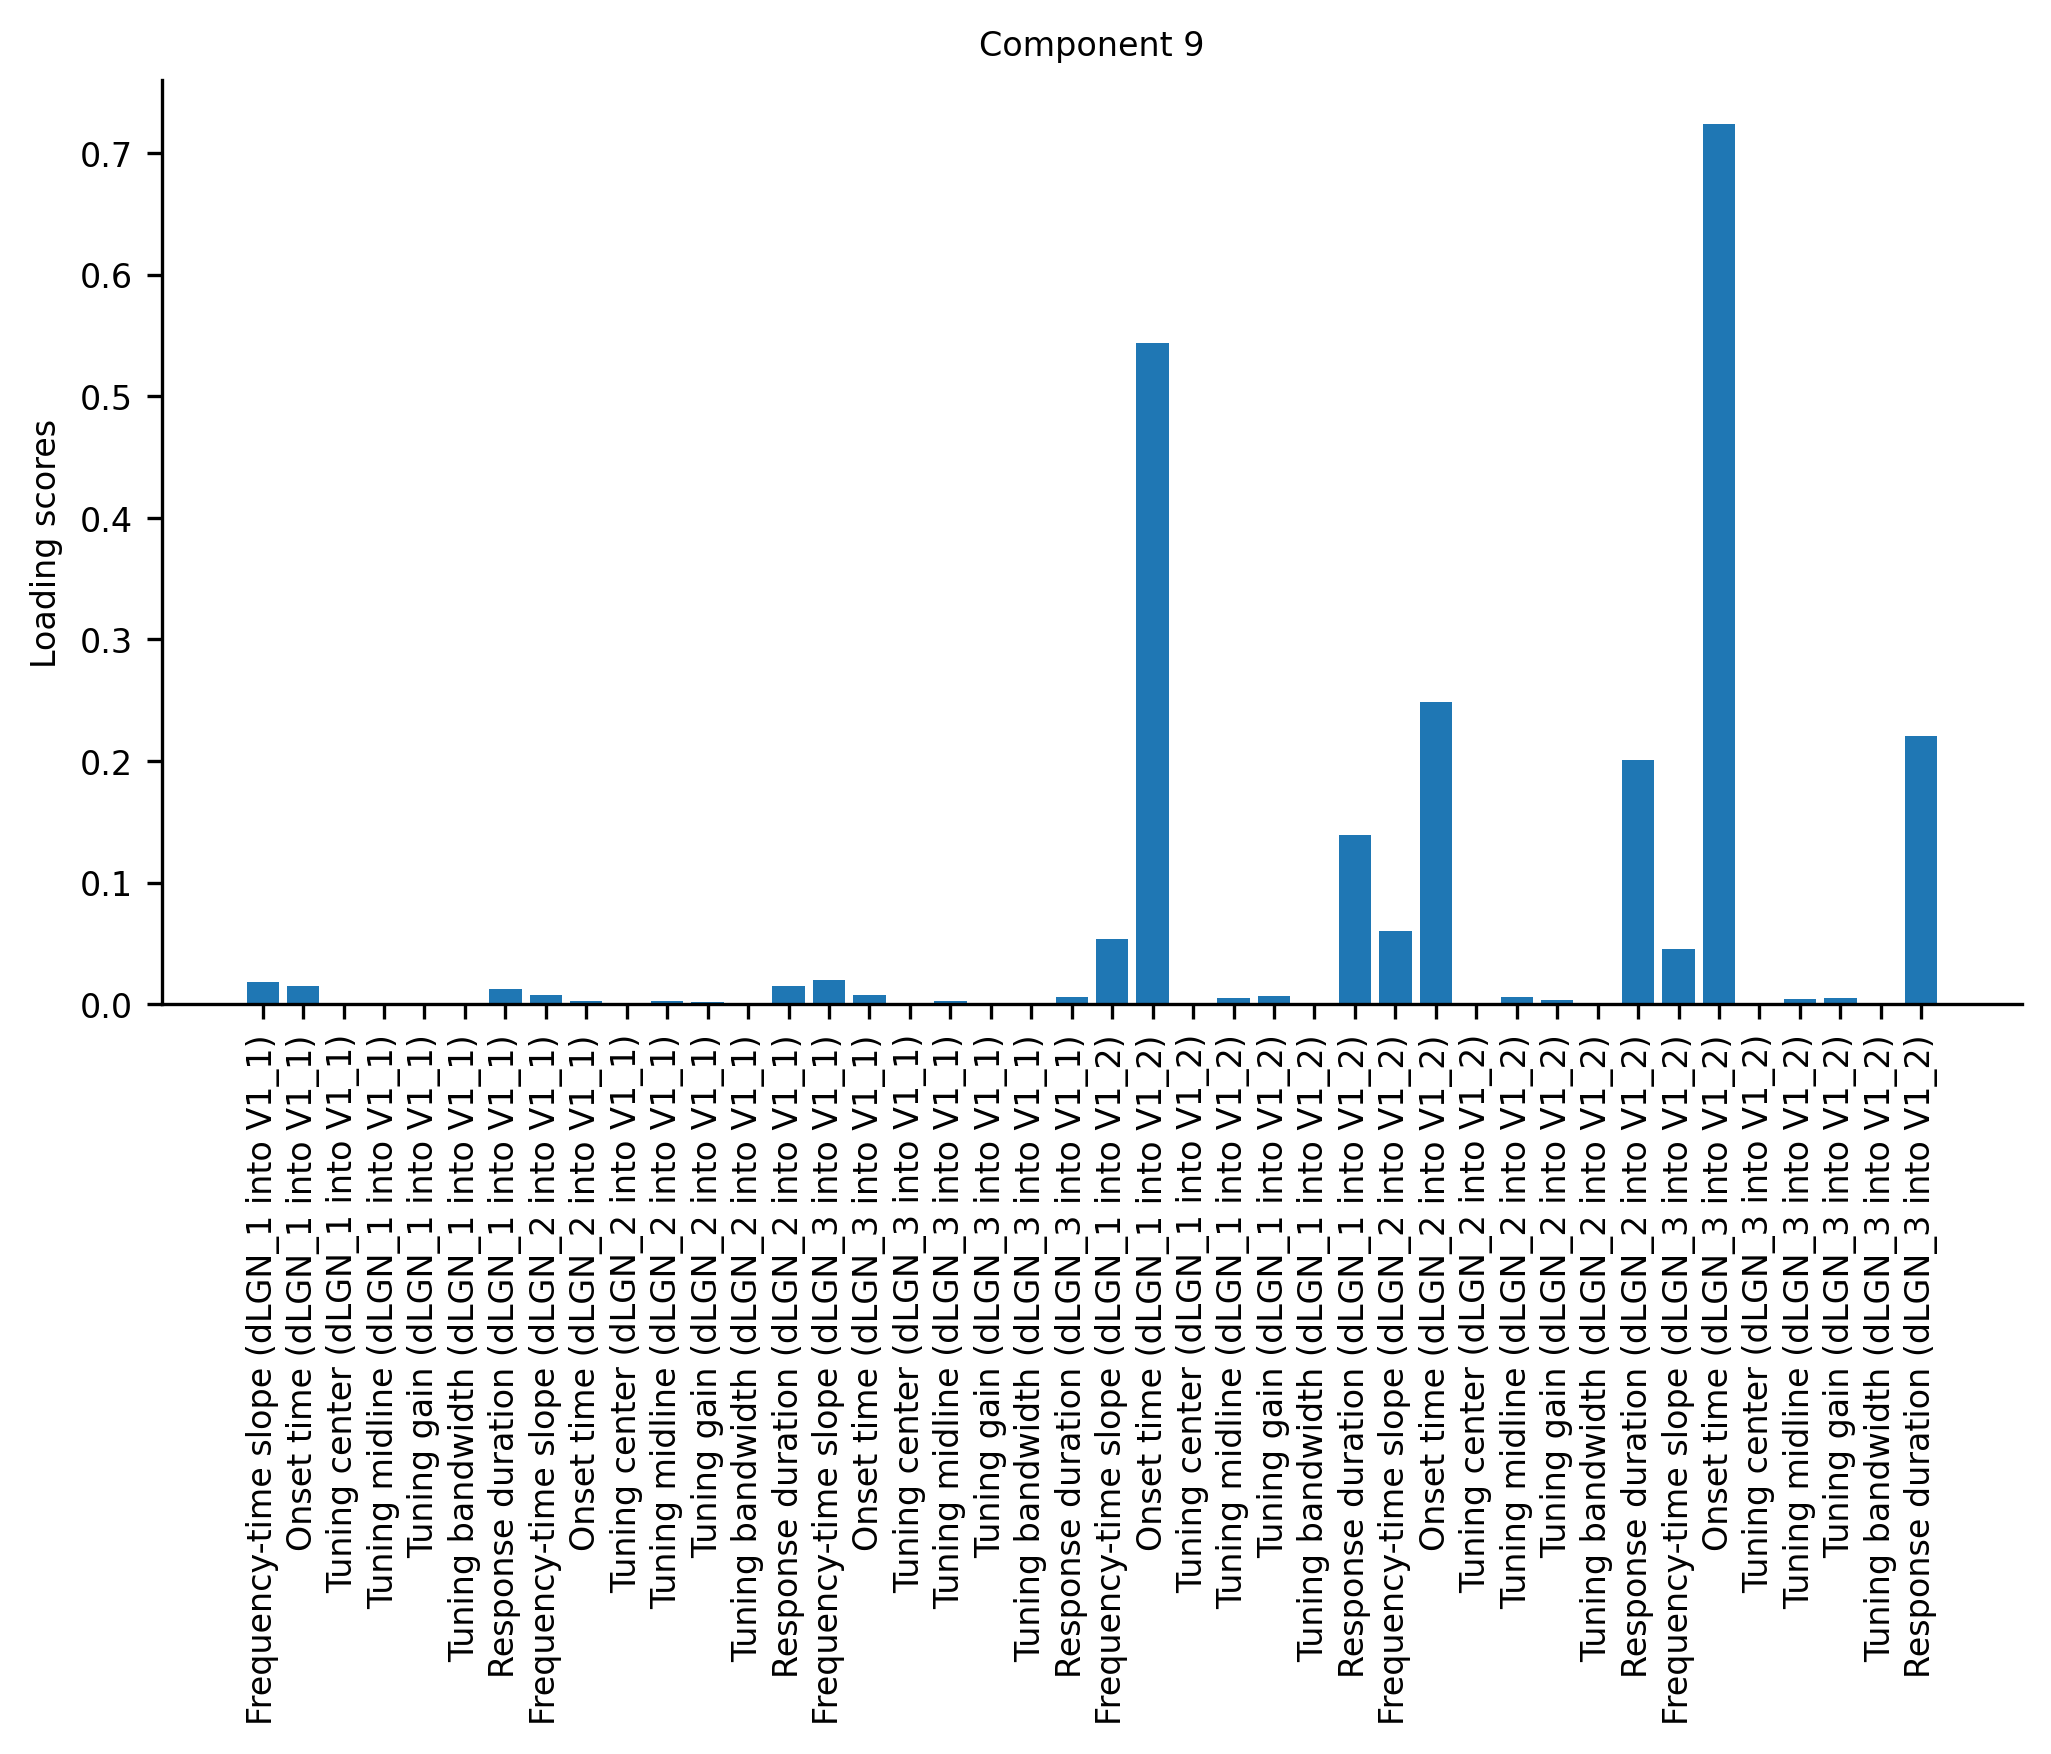

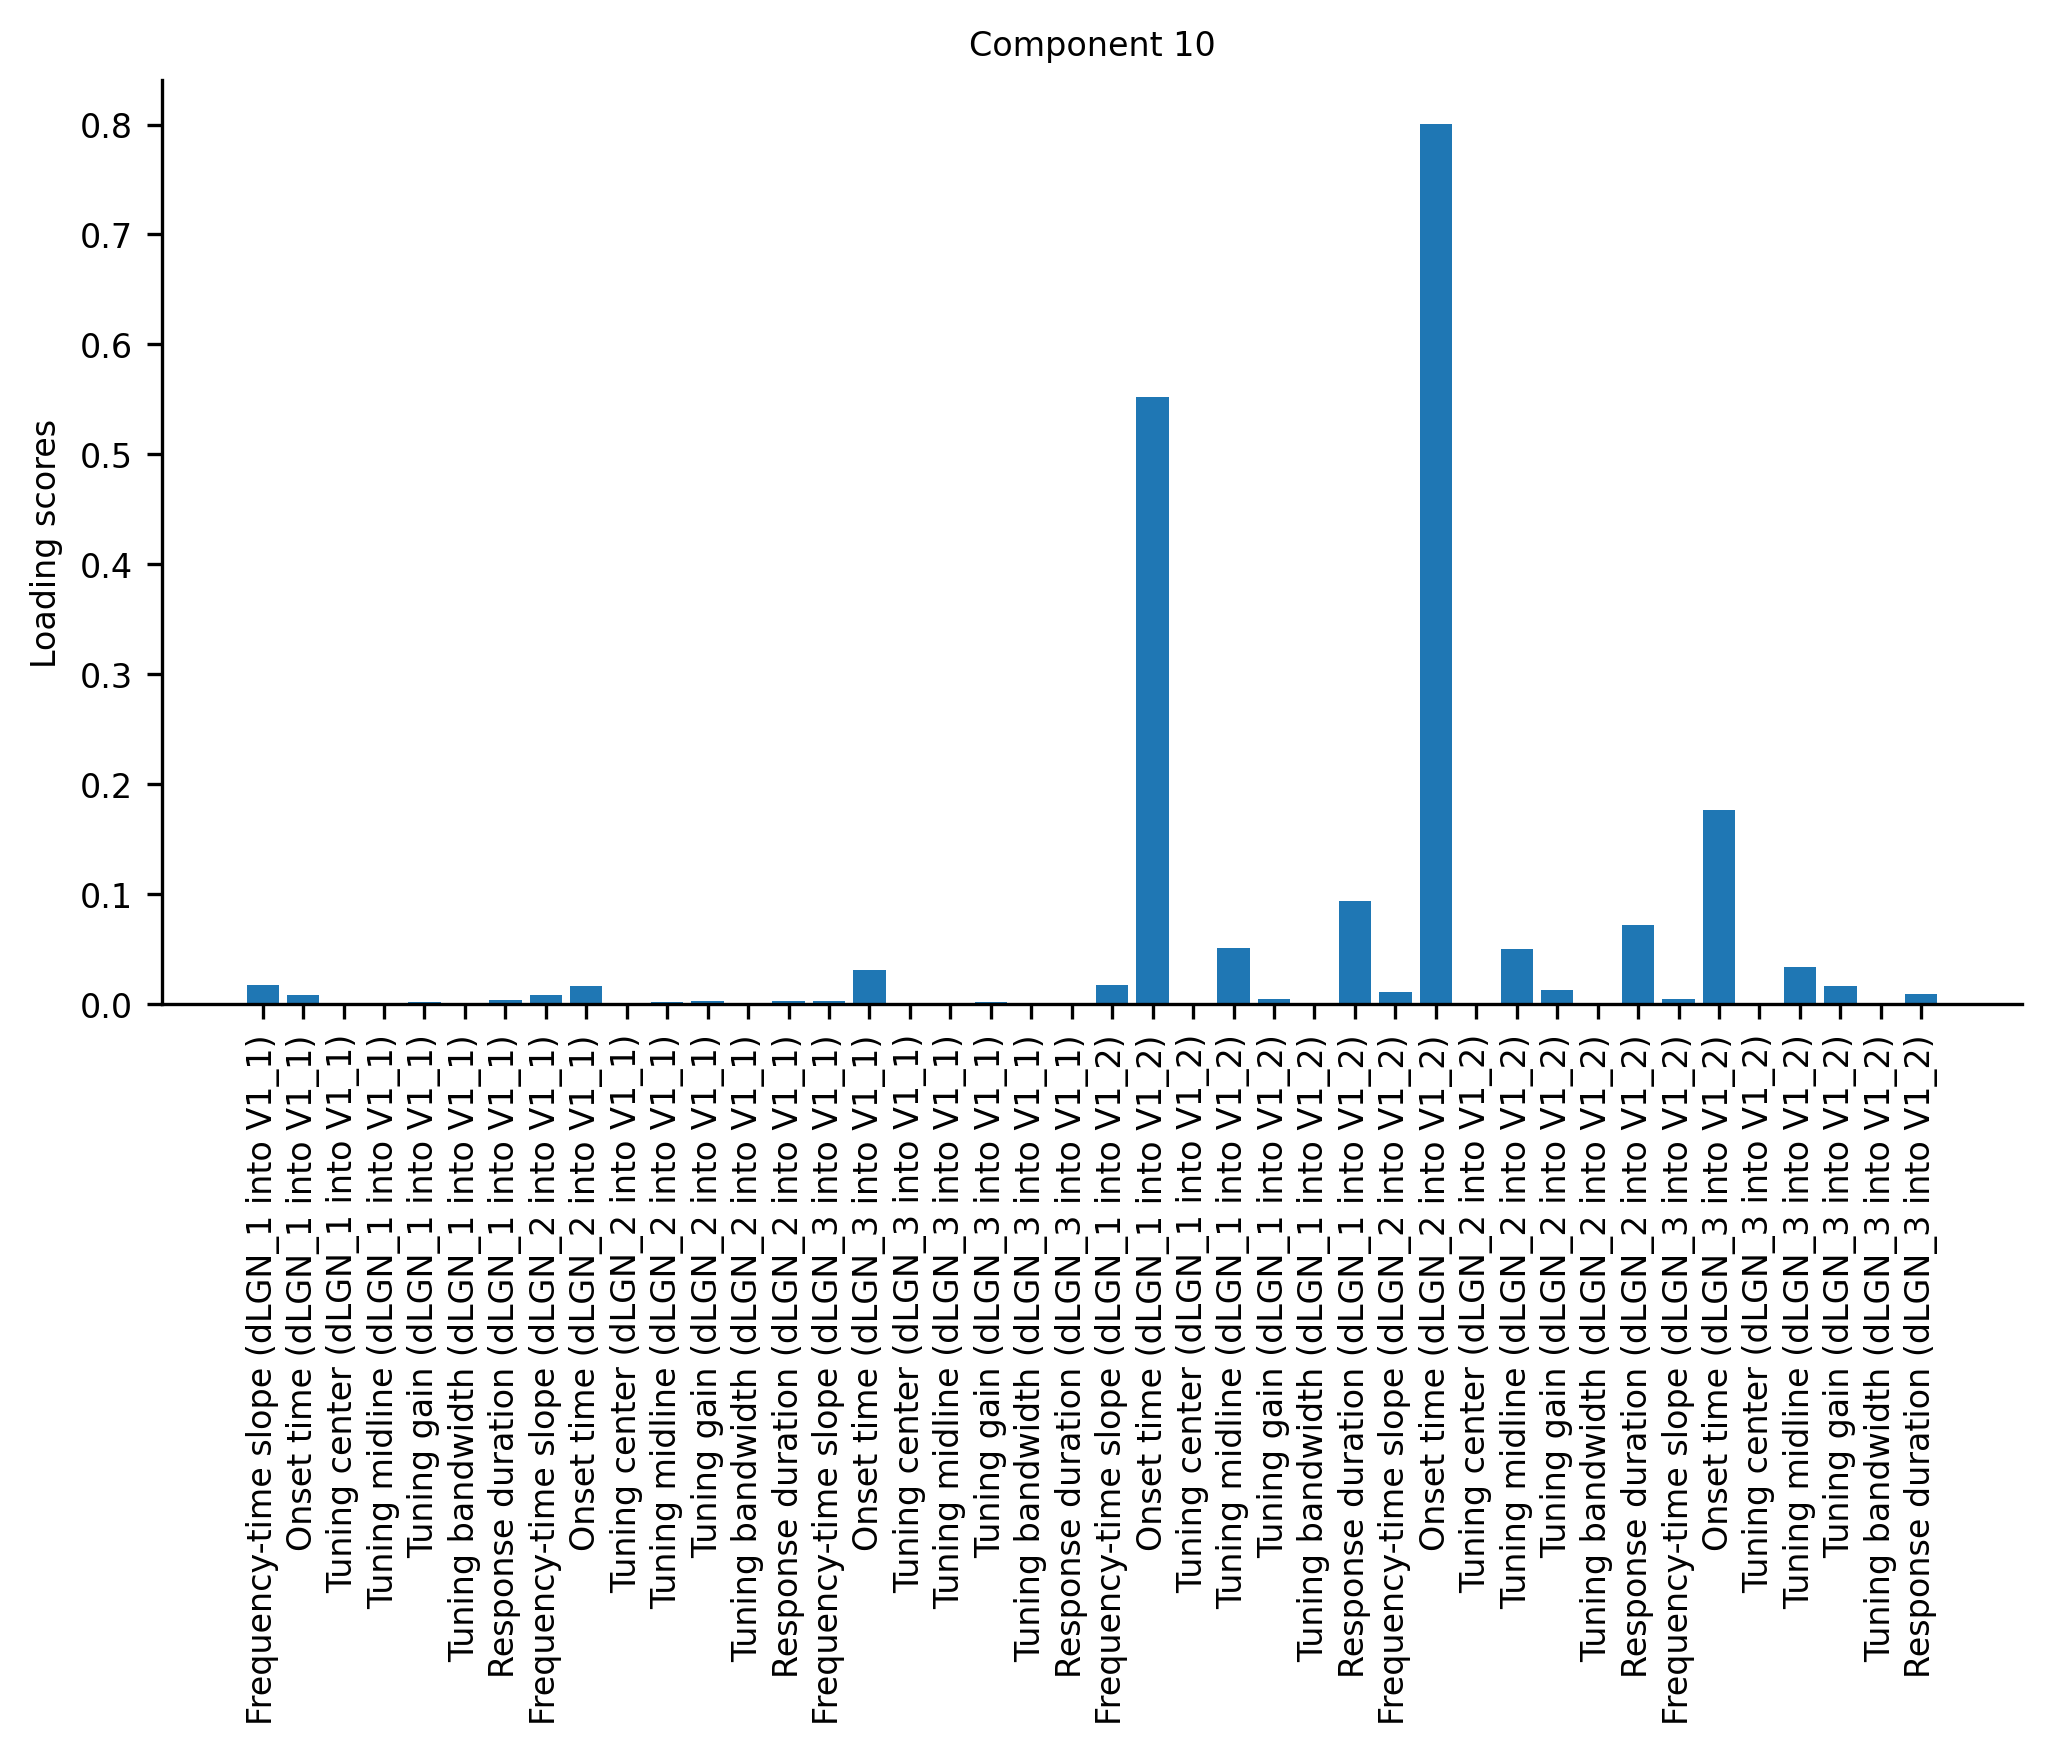

In [34]:
for i in range(10):
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.tick_params(labelsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar(np.arange(len(full_lgn_params)), np.abs(pca.components_[i]))
    ax.set_xticks(np.arange(len(full_lgn_params)))
    ax.set_xticklabels(param_names[:len(full_lgn_params)], rotation = 90)
    ax.set_ylabel("Loading scores", fontsize = fontsize)
    ax.set_title(f"Component {i+1}", fontsize = fontsize)

    figname = f'2d_model_pca_loadings_pc{i+1}_first_round.svg'
    savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    plt.savefig(savepath, transparent = False, facecolor = 'white',
            bbox_inches = 'tight', dpi = 300)